# Problem 4 - Measurement-Uncompute MCZ

This notebook prepares the next experiment: compare a reversible unitary multi-controlled-Z (MCZ) built from an AND tree against a dynamic measurement-uncompute version.

Definitions used below:

- `num_controls = k` means MCZ acts on `k` data qubits.
- The AND tree uses `k - 1` work ancillas for `k >= 3`.
- The unitary version computes the AND tree, applies `Z` to the root, then reverses the tree.
- The dynamic version computes the AND tree once, applies `Z` to the root, then removes AND ancillas by X-basis measurements plus conditional CZ corrections.
- The probabilistic echo benchmark is a decoded-output success test, not a fidelity estimate.
- The fidelity benchmark later in the notebook estimates output-state fidelity from Monte Carlo sampled Pauli projector terms, so it is compatible with hardware runs.


In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass, replace
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector, state_fidelity
from qiskit.result import marginal_counts
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error, thermal_relaxation_error

SEED = 1234
DEFAULT_SHOTS = 128
plt.style.use("seaborn-v0_8-whitegrid")

print("Problem 4 setup ready.")


Problem 4 setup ready.


## Balanced AND Tree

The same tree description is used by the unitary and dynamic MCZ builders. Leaves are data qubits `0 .. k-1`. Internal nodes are assigned to work ancillas `k .. k+a-1` in the logical tree index space.


In [2]:
def validate_num_controls(num_controls: int) -> int:
    num_controls = int(num_controls)
    if num_controls < 1:
        raise ValueError("num_controls must be at least 1.")
    return num_controls


def mcz_ancilla_count(num_controls: int) -> int:
    """Number of AND-tree work ancillas used by the tree implementation."""
    k = validate_num_controls(num_controls)
    return 0 if k <= 2 else k - 1


def balanced_and_tree(num_controls: int) -> dict:
    """Return bottom-up AND-tree levels.

    Each operation is `(left, right, target)` in a logical index space where
    leaves are `0..k-1` and ancillas are `k..k+a-1`.
    """
    k = validate_num_controls(num_controls)
    if k <= 2:
        return {"num_controls": k, "levels": [], "root": 0 if k == 1 else None, "ancilla_count": 0}

    levels = []
    next_ancilla = 0
    current = list(range(k))

    while len(current) > 1:
        level = []
        next_nodes = []
        index = 0
        while index < len(current):
            left = current[index]
            if index + 1 >= len(current):
                next_nodes.append(left)
                index += 1
                continue
            right = current[index + 1]
            target = k + next_ancilla
            next_ancilla += 1
            level.append((left, right, target))
            next_nodes.append(target)
            index += 2
        levels.append(level)
        current = next_nodes

    return {"num_controls": k, "levels": levels, "root": current[0], "ancilla_count": next_ancilla}


def tree_height(num_controls: int) -> int:
    return len(balanced_and_tree(num_controls)["levels"])


def tree_level_table(num_controls: int) -> pd.DataFrame:
    tree = balanced_and_tree(num_controls)
    rows = []
    for level_index, level in enumerate(tree["levels"]):
        for left, right, target in level:
            rows.append({"level": level_index, "left": left, "right": right, "target": target})
    return pd.DataFrame(rows)


display(tree_level_table(8))


,level,left,right,target
0,0,0,1,8
1,0,2,3,9
2,0,4,5,10
3,0,6,7,11
4,1,8,9,12
5,1,10,11,13
6,2,12,13,14


## MCZ Circuit Builders

The circuit builders expose both complete circuits and in-place application functions. The in-place functions make it easy to embed MCZ into Grover or into echo-test circuits.


,name,num_qubits,num_clbits,depth,ccx,cz,z,h,measure,if_else
0,unitary_mcz_4,7,0,5,6,0,1,0,0,0
1,dynamic_mcz_4,7,3,9,3,0,1,3,3,3


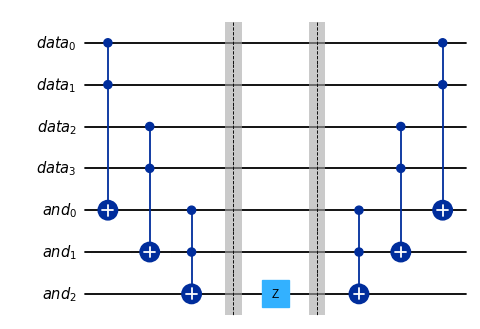

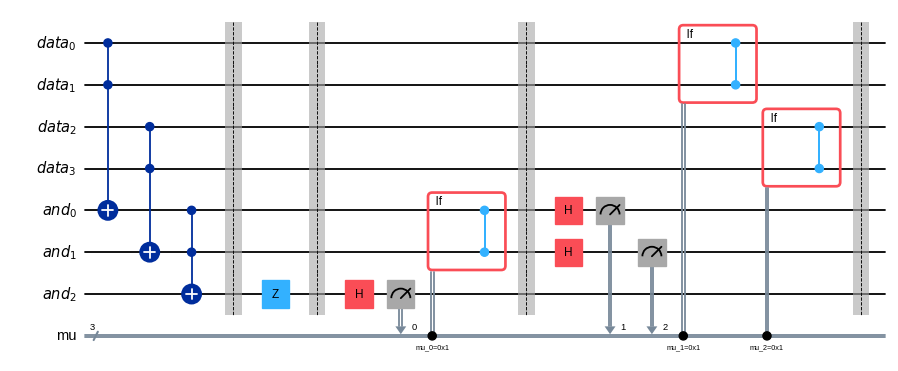

In [3]:
def _as_list(register_or_qubits: Iterable) -> list:
    return list(register_or_qubits) if register_or_qubits is not None else []


def _logical_qubit_map(controls, ancillas, num_controls: int) -> list:
    controls = _as_list(controls)
    ancillas = _as_list(ancillas)
    expected_ancillas = mcz_ancilla_count(num_controls)
    if len(controls) != num_controls:
        raise ValueError(f"Expected {num_controls} controls, got {len(controls)}.")
    if len(ancillas) != expected_ancillas:
        raise ValueError(f"Expected {expected_ancillas} ancillas, got {len(ancillas)}.")
    return controls + ancillas


def apply_unitary_mcz(qc: QuantumCircuit, controls, ancillas=None, add_barriers: bool = True) -> QuantumCircuit:
    """Apply a clean unitary MCZ using a reversible AND tree."""
    controls = _as_list(controls)
    k = validate_num_controls(len(controls))

    if k == 1:
        qc.z(controls[0])
        return qc
    if k == 2:
        qc.cz(controls[0], controls[1])
        return qc

    tree = balanced_and_tree(k)
    qmap = _logical_qubit_map(controls, ancillas, k)

    for level in tree["levels"]:
        for left, right, target in level:
            qc.ccx(qmap[left], qmap[right], qmap[target])

    if add_barriers:
        qc.barrier()
    qc.z(qmap[tree["root"]])
    if add_barriers:
        qc.barrier()

    for level in reversed(tree["levels"]):
        for left, right, target in reversed(level):
            qc.ccx(qmap[left], qmap[right], qmap[target])
    return qc


def apply_dynamic_mcz(qc: QuantumCircuit, controls, ancillas=None, measure_bits=None, add_barriers: bool = True) -> QuantumCircuit:
    """Apply MCZ using forward AND computation and measurement-uncompute cleanup."""
    controls = _as_list(controls)
    k = validate_num_controls(len(controls))

    if k == 1:
        qc.z(controls[0])
        return qc
    if k == 2:
        qc.cz(controls[0], controls[1])
        return qc

    tree = balanced_and_tree(k)
    qmap = _logical_qubit_map(controls, ancillas, k)
    measure_bits = _as_list(measure_bits)
    if len(measure_bits) != tree["ancilla_count"]:
        raise ValueError(f"Expected {tree['ancilla_count']} measurement bits, got {len(measure_bits)}.")

    for level in tree["levels"]:
        for left, right, target in level:
            qc.ccx(qmap[left], qmap[right], qmap[target])

    if add_barriers:
        qc.barrier()
    qc.z(qmap[tree["root"]])
    if add_barriers:
        qc.barrier()

    bit_index = 0
    for level in reversed(tree["levels"]):
        measured_this_level = []
        for left, right, target in level:
            bit = measure_bits[bit_index]
            qc.h(qmap[target])
            qc.measure(qmap[target], bit)
            measured_this_level.append((left, right, bit))
            bit_index += 1

        for left, right, bit in measured_this_level:
            with qc.if_test((bit, 1)):
                qc.cz(qmap[left], qmap[right])

        if add_barriers:
            qc.barrier()

    return qc


def build_unitary_mcz(num_controls: int, add_barriers: bool = True) -> QuantumCircuit:
    k = validate_num_controls(num_controls)
    ancilla_count = mcz_ancilla_count(k)
    data = QuantumRegister(k, "data")
    regs = [data]
    anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    if anc is not None:
        regs.append(anc)
    qc = QuantumCircuit(*regs, name=f"unitary_mcz_{k}")
    apply_unitary_mcz(qc, data, anc or [], add_barriers=add_barriers)
    qc.metadata = {"implementation": "unitary", "num_controls": k, "ancilla_count": ancilla_count}
    return qc


def build_dynamic_mcz(num_controls: int, add_barriers: bool = True) -> QuantumCircuit:
    k = validate_num_controls(num_controls)
    ancilla_count = mcz_ancilla_count(k)
    data = QuantumRegister(k, "data")
    regs = [data]
    anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    meas = ClassicalRegister(ancilla_count, "mu") if ancilla_count else None
    if anc is not None:
        regs.append(anc)
    if meas is not None:
        regs.append(meas)
    qc = QuantumCircuit(*regs, name=f"dynamic_mcz_{k}")
    apply_dynamic_mcz(qc, data, anc or [], meas or [], add_barriers=add_barriers)
    qc.metadata = {"implementation": "dynamic", "num_controls": k, "ancilla_count": ancilla_count}
    return qc


def mcz_circuit_summary(qc: QuantumCircuit) -> dict:
    ops = qc.count_ops()
    return {
        "name": qc.name,
        "num_qubits": qc.num_qubits,
        "num_clbits": qc.num_clbits,
        "depth": qc.depth(),
        "ccx": int(ops.get("ccx", 0)),
        "cz": int(ops.get("cz", 0)),
        "z": int(ops.get("z", 0)),
        "h": int(ops.get("h", 0)),
        "measure": int(ops.get("measure", 0)),
        "if_else": int(ops.get("if_else", 0)),
    }


example_k = 4
unitary_example = build_unitary_mcz(example_k, add_barriers=True)
dynamic_example = build_dynamic_mcz(example_k, add_barriers=True)
display(pd.DataFrame([mcz_circuit_summary(unitary_example), mcz_circuit_summary(dynamic_example)]))
display(unitary_example.draw("mpl", fold=-1, scale=0.65))
display(dynamic_example.draw("mpl", fold=-1, scale=0.65))


## MCZ Circuit Visualizations

The next cell draws the two MCZ implementations for `k = 2, 4, 8`. The unitary circuit computes the AND tree and reverses it. The dynamic circuit computes the same forward AND tree, then measurement-uncomputes the ancillas with X-basis measurements and conditional CZ corrections.

,name,num_qubits,num_clbits,depth,ccx,cz,z,h,measure,if_else
0,unitary_mcz_2,2,0,1,0,1,0,0,0,0
1,dynamic_mcz_2,2,0,1,0,1,0,0,0,0
2,unitary_mcz_4,7,0,5,6,0,1,0,0,0
3,dynamic_mcz_4,7,3,9,3,0,1,3,3,3
4,unitary_mcz_8,15,0,7,14,0,1,0,0,0
5,dynamic_mcz_8,15,7,13,7,0,1,7,7,7


### k=2, unitary MCZ

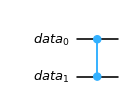

### k=2, dynamic MCZ

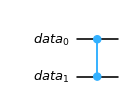

### k=4, unitary MCZ

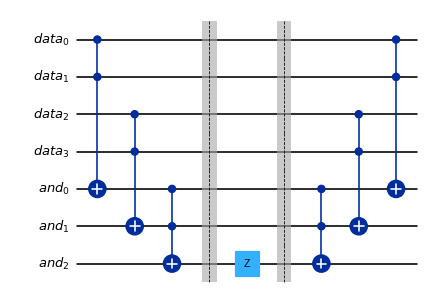

### k=4, dynamic MCZ

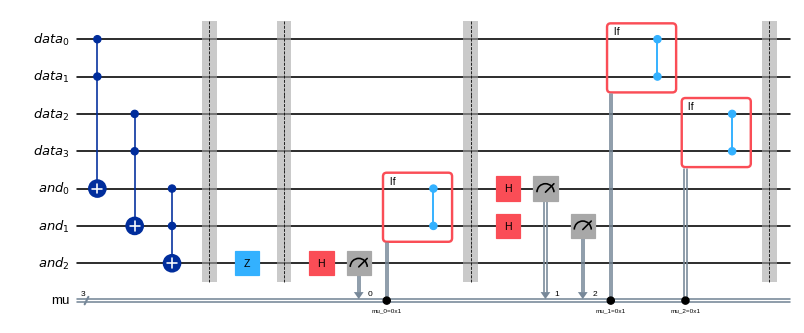

### k=8, unitary MCZ

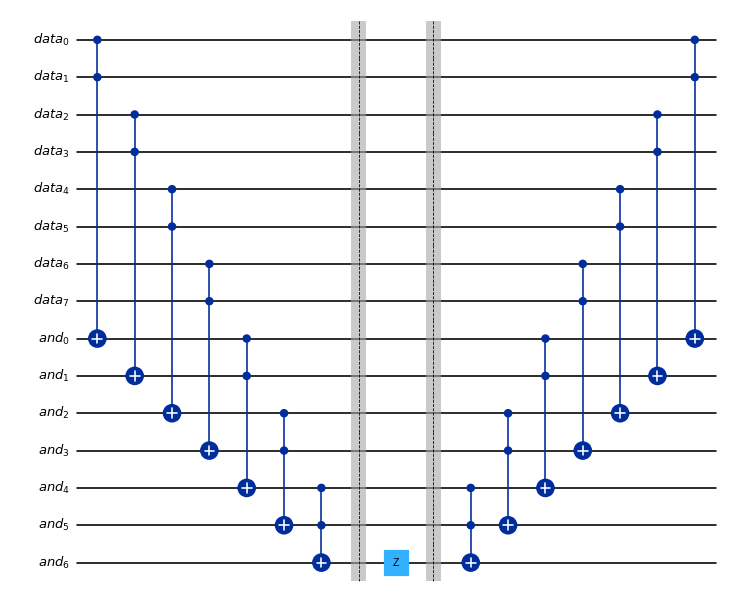

### k=8, dynamic MCZ

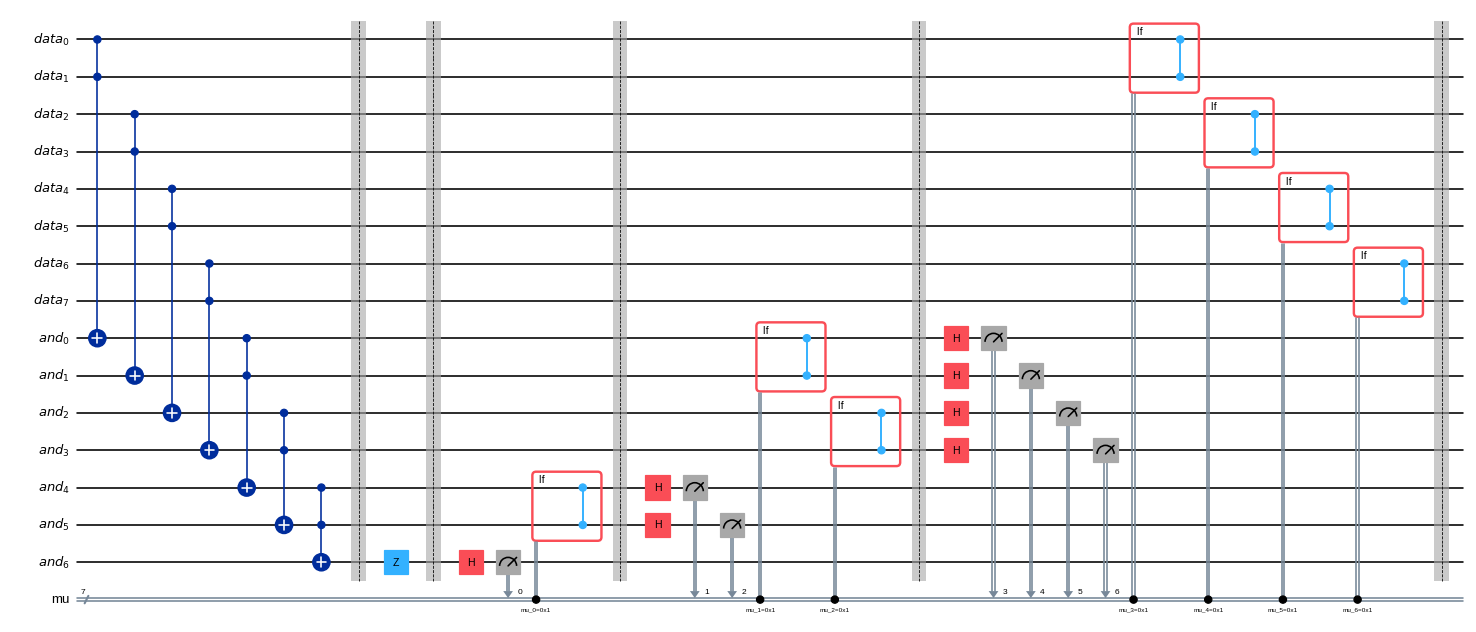

In [4]:
VISUALIZATION_CONTROL_VALUES = [2, 4, 8]
VISUALIZATION_IMPLEMENTATIONS = ["unitary", "dynamic"]

visualization_circuits = []
for k in VISUALIZATION_CONTROL_VALUES:
    for implementation in VISUALIZATION_IMPLEMENTATIONS:
        circuit = build_unitary_mcz(k, add_barriers=True) if implementation == "unitary" else build_dynamic_mcz(k, add_barriers=True)
        visualization_circuits.append(circuit)

visualization_summary = pd.DataFrame([mcz_circuit_summary(circuit) for circuit in visualization_circuits])
display(visualization_summary)

for circuit in visualization_circuits:
    implementation = circuit.metadata["implementation"]
    k = circuit.metadata["num_controls"]
    display(Markdown(f"### k={k}, {implementation} MCZ"))
    display(circuit.draw("mpl", fold=80, scale=0.58, idle_wires=False))

## Probabilistic Echo Verification

This section is a fast decoded-output probability check. It prepares `|+>^k`, applies a clean unitary reference MCZ, applies the candidate MCZ, and measures whether the data qubits decode to `0...0` in the X basis.

The reference block is placed before the candidate block so both blocks reuse one AND-tree workspace. The probabilistic echo circuit therefore uses `2k - 1` qubits for `k >= 3`, not `3k - 2`.

This is useful as a sanity check, but it is not the hardware fidelity metric used later.


In [4]:
def build_mcz_echo_test(num_controls: int, implementation: str, add_barriers: bool = False) -> QuantumCircuit:
    """Build a shared-workspace MCZ echo probability test.

    `implementation` is either `unitary` or `dynamic` for the candidate block.
    The clean unitary reference block is applied before the candidate block and
    returns the shared AND-tree workspace to |0>, so the candidate can reuse it.
    Width is k + (k - 1) = 2k - 1 for k >= 3.
    """
    k = validate_num_controls(num_controls)
    implementation = implementation.lower()
    if implementation not in {"unitary", "dynamic"}:
        raise ValueError("implementation must be 'unitary' or 'dynamic'.")

    ancilla_count = mcz_ancilla_count(k)
    data = QuantumRegister(k, "data")
    regs = [data]

    shared_anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    if shared_anc is not None:
        regs.append(shared_anc)

    dynamic_bits = ClassicalRegister(ancilla_count, "mu") if implementation == "dynamic" and ancilla_count else None
    out = ClassicalRegister(k, "out")
    if dynamic_bits is not None:
        regs.append(dynamic_bits)
    regs.append(out)

    qc = QuantumCircuit(*regs, name=f"mcz_echo_shared_{implementation}_{k}")
    for qubit in data:
        qc.h(qubit)

    # MCZ is self-inverse. The reference block prepares the ideal decoded target;
    # the candidate block should undo it and return the data to |+>^k.
    apply_unitary_mcz(qc, data, shared_anc or [], add_barriers=add_barriers)
    if implementation == "unitary":
        apply_unitary_mcz(qc, data, shared_anc or [], add_barriers=add_barriers)
    else:
        apply_dynamic_mcz(qc, data, shared_anc or [], dynamic_bits or [], add_barriers=add_barriers)

    for qubit in data:
        qc.h(qubit)
    for index, qubit in enumerate(data):
        qc.measure(qubit, out[index])

    qc.metadata = {
        "experiment": "mcz_probabilistic_echo_shared_workspace",
        "implementation": implementation,
        "num_controls": k,
        "workspace_ancilla_count": ancilla_count,
        "echo_order": "reference_then_candidate",
    }
    return qc


def classical_register_indices(circuit: QuantumCircuit, register_name: str) -> list[int]:
    for creg in circuit.cregs:
        if creg.name == register_name:
            return [circuit.clbits.index(bit) for bit in creg]
    raise ValueError(f"No classical register named {register_name!r}.")


def register_counts(counts: dict, circuit: QuantumCircuit, register_name: str) -> dict:
    return dict(marginal_counts(counts, indices=classical_register_indices(circuit, register_name)))


def echo_success_probability(counts: dict, circuit: QuantumCircuit, register_name: str = "out") -> float:
    out_counts = register_counts(counts, circuit, register_name)
    shots = sum(out_counts.values())
    if shots == 0:
        return 0.0
    zero_key = "0" * len(classical_register_indices(circuit, register_name))
    return out_counts.get(zero_key, 0) / shots


def run_mcz_echo(
    num_controls: int,
    implementation: str,
    noise_model: NoiseModel | None = None,
    shots: int = DEFAULT_SHOTS,
    seed: int = SEED,
) -> dict:
    circuit = build_mcz_echo_test(num_controls, implementation=implementation, add_barriers=False)
    simulator = AerSimulator(method="matrix_product_state", noise_model=noise_model, seed_simulator=seed)
    result = simulator.run(circuit, shots=shots, seed_simulator=seed).result()
    counts = result.get_counts(0)
    out_counts = register_counts(counts, circuit, "out")
    success = echo_success_probability(counts, circuit, "out")
    return {
        "num_controls": int(num_controls),
        "implementation": implementation,
        "shots": int(shots),
        "echo_success_probability": float(success),
        "out_counts": out_counts,
        "raw_counts": counts,
        **mcz_circuit_summary(circuit),
    }


def run_ideal_echo_verification(max_controls: int = 8, shots: int = 256) -> pd.DataFrame:
    rows = []
    for k in range(1, max_controls + 1):
        for implementation in ["unitary", "dynamic"]:
            rows.append(run_mcz_echo(k, implementation=implementation, noise_model=None, shots=shots))
    return pd.DataFrame(rows)


ideal_echo_df = run_ideal_echo_verification(max_controls=7, shots=128)
display(ideal_echo_df[["num_controls", "implementation", "num_qubits", "echo_success_probability", "ccx", "cz", "measure", "if_else"]])
assert float(ideal_echo_df["echo_success_probability"].min()) == 1.0
for k in range(3, 8):
    assert int(ideal_echo_df.loc[ideal_echo_df["num_controls"] == k, "num_qubits"].max()) == 2 * k - 1
print("Ideal shared-workspace echo verification passed for k=1..7.")


,num_controls,implementation,num_qubits,echo_success_probability,ccx,cz,measure,if_else
0,1,unitary,1,1.0,0,0,1,0
1,1,dynamic,1,1.0,0,0,1,0
2,2,unitary,2,1.0,0,2,2,0
3,2,dynamic,2,1.0,0,2,2,0
4,3,unitary,5,1.0,8,0,3,0
5,3,dynamic,5,1.0,6,0,5,2
6,4,unitary,7,1.0,12,0,4,0
7,4,dynamic,7,1.0,9,0,7,3
8,5,unitary,9,1.0,16,0,5,0
9,5,dynamic,9,1.0,12,0,9,4


Ideal shared-workspace echo verification passed for k=1..7.


## Resource Model

This table separates the expensive non-Clifford CCX work from measurement and Clifford corrections. For the dynamic circuit, `N_CZ_conditional_max` is the maximum number of conditional CZ corrections. In a stochastic run, only the branches whose measurement bit is 1 physically apply the correction, but the worst-case budget is useful for hardware planning.

Timing columns are normalized to one native two-qubit-gate duration. They are an editable planning model, not calibrated hardware timing. `t_idle_2q_units` is the dynamic cleanup wait from X measurement plus feed-forward layers; it is zero for the unitary version in this first-pass model.

Local exact noisy simulation is capped at `k <= 7` by default. Larger `k` should use resource estimates first, then selective backend-aware experiments.


In [4]:
# Editable first-pass timing model, in units of one native two-qubit gate duration.
CCX_DURATION_2Q_UNITS = 6.0
CZ_DURATION_2Q_UNITS = 1.0
Z_DURATION_2Q_UNITS = 0.0
X_MEAS_DURATION_2Q_UNITS = 4.0
FEEDFORWARD_DURATION_2Q_UNITS = 1.0

RESOURCE_CONTROL_VALUES = [1, 2, 3, 4, 5, 6, 7]


def mcz_resource_formula(num_controls: int, implementation: str) -> dict:
    k = validate_num_controls(num_controls)
    implementation = implementation.lower()
    if implementation not in {"unitary", "dynamic"}:
        raise ValueError("implementation must be 'unitary' or 'dynamic'.")

    anc = mcz_ancilla_count(k)
    height = tree_height(k)

    if k == 1:
        base = {"N_CCX": 0, "N_Z": 1, "N_CZ_static": 0, "N_X_meas": 0, "N_CZ_conditional_max": 0, "D_CCX": 0}
    elif k == 2:
        base = {"N_CCX": 0, "N_Z": 0, "N_CZ_static": 1, "N_X_meas": 0, "N_CZ_conditional_max": 0, "D_CCX": 0}
    elif implementation == "unitary":
        base = {"N_CCX": 2 * anc, "N_Z": 1, "N_CZ_static": 0, "N_X_meas": 0, "N_CZ_conditional_max": 0, "D_CCX": 2 * height}
    else:
        base = {"N_CCX": anc, "N_Z": 1, "N_CZ_static": 0, "N_X_meas": anc, "N_CZ_conditional_max": anc, "D_CCX": height}

    cleanup_layers = height if implementation == "dynamic" and k >= 3 else 0
    n_gate_total_worst = base["N_CCX"] + base["N_Z"] + base["N_CZ_static"] + base["N_CZ_conditional_max"]
    n_clifford_gate_worst = base["N_Z"] + base["N_CZ_static"] + base["N_CZ_conditional_max"]
    t_idle_2q_units = cleanup_layers * (X_MEAS_DURATION_2Q_UNITS + FEEDFORWARD_DURATION_2Q_UNITS)
    estimated_wall_time_2q_units = (
        base["D_CCX"] * CCX_DURATION_2Q_UNITS
        + (1 if base["N_CZ_static"] > 0 else 0) * CZ_DURATION_2Q_UNITS
        + (1 if base["N_Z"] > 0 else 0) * Z_DURATION_2Q_UNITS
        + cleanup_layers * (X_MEAS_DURATION_2Q_UNITS + FEEDFORWARD_DURATION_2Q_UNITS + CZ_DURATION_2Q_UNITS)
    )

    return {
        "num_controls": k,
        "implementation": implementation,
        "ancilla_count": anc,
        "tree_height": height,
        **base,
        "N_gate_total_worst": n_gate_total_worst,
        "N_nonclifford_gate": base["N_CCX"],
        "N_clifford_gate_worst": n_clifford_gate_worst,
        "N_measure": base["N_X_meas"],
        "D_cleanup_layers": cleanup_layers,
        "t_idle_2q_units": t_idle_2q_units,
        "estimated_wall_time_2q_units": estimated_wall_time_2q_units,
    }


def mcz_resource_table(control_values: Iterable[int], include_circuit_depth: bool = True) -> pd.DataFrame:
    rows = []
    for k in control_values:
        for implementation in ["unitary", "dynamic"]:
            row = mcz_resource_formula(k, implementation)
            if include_circuit_depth:
                qc = build_unitary_mcz(k, add_barriers=False) if implementation == "unitary" else build_dynamic_mcz(k, add_barriers=False)
                summary = mcz_circuit_summary(qc)
                row.update({
                    "circuit_num_qubits": summary["num_qubits"],
                    "circuit_num_clbits": summary["num_clbits"],
                    "circuit_depth_high_level": summary["depth"],
                    "circuit_measure_ops": summary["measure"],
                    "circuit_if_else_ops": summary["if_else"],
                })
            rows.append(row)
    return pd.DataFrame(rows)


resource_df = mcz_resource_table(RESOURCE_CONTROL_VALUES)
resource_display_columns = [
    "num_controls",
    "implementation",
    "ancilla_count",
    "tree_height",
    "circuit_num_qubits",
    "circuit_num_clbits",
    "circuit_depth_high_level",
    "D_CCX",
    "D_cleanup_layers",
    "N_gate_total_worst",
    "N_nonclifford_gate",
    "N_clifford_gate_worst",
    "N_measure",
    "N_CCX",
    "N_CZ_conditional_max",
    "t_idle_2q_units",
    "estimated_wall_time_2q_units",
]
display(resource_df[resource_display_columns])


,num_controls,implementation,ancilla_count,tree_height,circuit_num_qubits,circuit_num_clbits,circuit_depth_high_level,D_CCX,D_cleanup_layers,N_gate_total_worst,N_nonclifford_gate,N_clifford_gate_worst,N_measure,N_CCX,N_CZ_conditional_max,t_idle_2q_units,estimated_wall_time_2q_units
0,1,unitary,0,0,1,0,1,0,0,1,0,1,0,0,0,0.0,0.0
1,1,dynamic,0,0,1,0,1,0,0,1,0,1,0,0,0,0.0,0.0
2,2,unitary,0,0,2,0,1,0,0,1,0,1,0,0,0,0.0,1.0
3,2,dynamic,0,0,2,0,1,0,0,1,0,1,0,0,0,0.0,1.0
4,3,unitary,2,2,5,0,5,4,0,5,4,1,0,4,0,0.0,24.0
5,3,dynamic,2,2,5,2,9,2,2,5,2,3,2,2,2,10.0,24.0
6,4,unitary,3,2,7,0,5,4,0,7,6,1,0,6,0,0.0,24.0
7,4,dynamic,3,2,7,3,9,2,2,7,3,4,3,3,3,10.0,24.0
8,5,unitary,4,3,9,0,7,6,0,9,8,1,0,8,0,0.0,36.0
9,5,dynamic,4,3,9,4,13,3,3,9,4,5,4,4,4,15.0,36.0


## Resource Scaling for k=2..40

This section compares the unitary and dynamic MCZ implementations for even `k` from 2 through 40.

Columns use the high-level circuit builders plus the first-pass resource model used throughout this notebook. `circuit_depth_high_level` is Qiskit's depth of the logical circuit. `estimated_2q_depth_worst` and `estimated_2q_gate_count_worst` count each CCX as six native two-qubit units, matching `CCX_DURATION_2Q_UNITS = 6.0`; conditional CZ corrections are counted in the dynamic worst case.

,num_controls,implementation,num_qubits,num_clbits,circuit_depth_high_level,estimated_2q_depth_worst,estimated_2q_gate_count_worst,if_test_count,N_CCX,N_measure,N_CZ_conditional_max
0,2,unitary,2,0,1,1.0,1,0,0,0,0
1,2,dynamic,2,0,1,1.0,1,0,0,0,0
2,4,unitary,7,0,5,24.0,36,0,6,0,0
3,4,dynamic,7,3,9,14.0,21,3,3,3,3
4,6,unitary,11,0,7,36.0,60,0,10,0,0
5,6,dynamic,11,5,13,21.0,35,5,5,5,5
6,8,unitary,15,0,7,36.0,84,0,14,0,0
7,8,dynamic,15,7,13,21.0,49,7,7,7,7
8,10,unitary,19,0,9,48.0,108,0,18,0,0
9,10,dynamic,19,9,17,28.0,63,9,9,9,9


circuit_depth_high_level         estimated_2q_depth_worst  \
implementation                  dynamic unitary                  dynamic   
num_controls                                                               
2                                     1       1                      1.0   
4                                     9       5                     14.0   
6                                    13       7                     21.0   
8                                    13       7                     21.0   
10                                   17       9                     28.0   
12                                   17       9                     28.0   
14                                   17       9                     28.0   
16                                   17       9                     28.0   
18                                   21      11                     35.0   
20                                   21      11                     35.0   
22                                   21      11                     35.0   
24                                   21      11                     35.0   
26                                   21      11                     35.0   
28                                   21      11                     35.0   
30                                   21      11                     35.0   
32                                   21      11                     35.0   
34                                   25      13                     42.0   
36                                   25      13                     42.0   
38                                   25      13                     42.0   
40                                   25      13                     42.0   

                       estimated_2q_gate_count_worst         if_test_count  \
implementation unitary                       dynamic unitary       dynamic   
num_controls                                                                 
2                  1.0                             1       1             0   
4                 24.0                            21      36             3   
6                 36.0                            35      60             5   
8                 36.0                            49      84             7   
10                48.0                            63     108             9   
12                48.0                            77     132            11   
14                48.0                            91     156            13   
16                48.0                           105     180            15   
18                60.0                           119     204            17   
20                60.0                           133     228            19   
22                60.0                           147     252            21   
24                60.0                           161     276            23   
26                60.0                           175     300            25   
28                60.0                           189     324            27   
30                60.0                           203     348            29   
32                60.0                           217     372            31   
34                72.0                           231     396            33   
36                72.0                           245     420            35   
38                72.0                           259     444            37   
40                72.0                           273     468            39   

                        
implementation unitary  
num_controls            
2                    0  
4                    0  
6                    0  
8                    0  
10                   0  
12                   0  
14                   0  
16                   0  
18                   0  
20                   0  
22                   0  
24                   0  
26                   0  
28                   0  
30                   0  
32                   

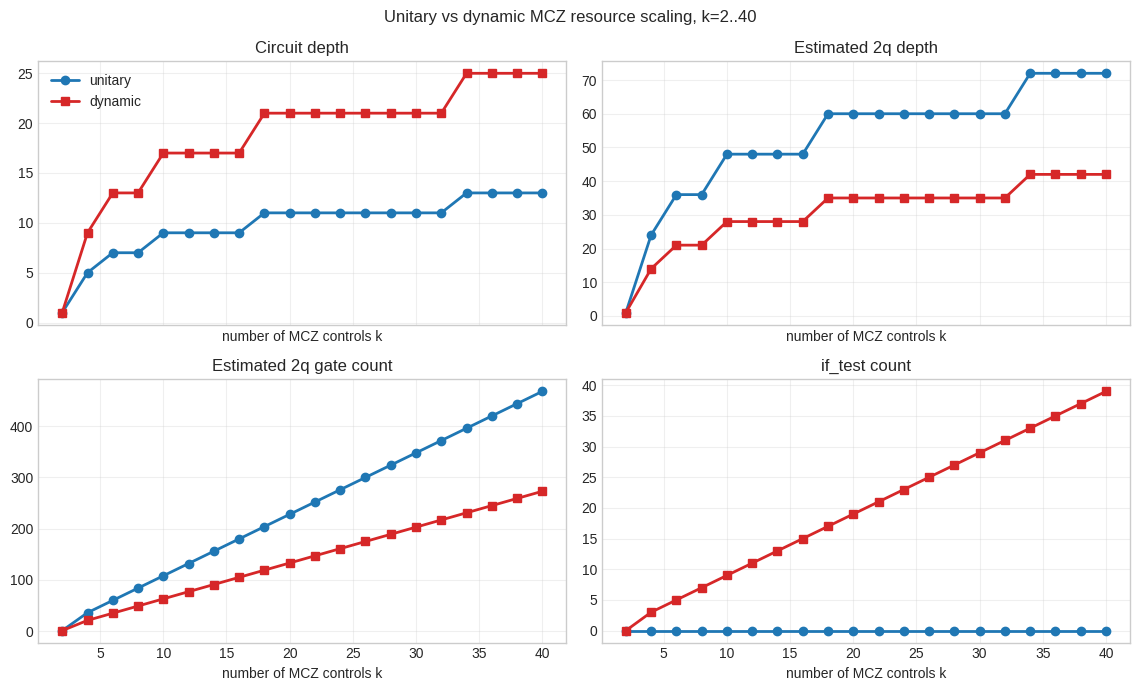

In [5]:
RESOURCE_SCALING_K_VALUES = list(range(2, 41, 2))
CCX_EQUIV_2Q_GATE_COUNT = int(CCX_DURATION_2Q_UNITS)
CCX_EQUIV_2Q_DEPTH = int(CCX_DURATION_2Q_UNITS)


def mcz_resource_scaling_table(control_values=RESOURCE_SCALING_K_VALUES) -> pd.DataFrame:
    rows = []
    for k in control_values:
        for implementation in ["unitary", "dynamic"]:
            qc = build_unitary_mcz(k, add_barriers=False) if implementation == "unitary" else build_dynamic_mcz(k, add_barriers=False)
            summary = mcz_circuit_summary(qc)
            formula = mcz_resource_formula(k, implementation)

            estimated_2q_gate_count_worst = (
                formula["N_CCX"] * CCX_EQUIV_2Q_GATE_COUNT
                + formula["N_CZ_static"]
                + formula["N_CZ_conditional_max"]
            )
            estimated_2q_depth_worst = (
                formula["D_CCX"] * CCX_EQUIV_2Q_DEPTH
                + (1 if formula["N_CZ_static"] > 0 else 0)
                + formula["D_cleanup_layers"]
            )

            rows.append({
                "num_controls": int(k),
                "implementation": implementation,
                "num_qubits": int(summary["num_qubits"]),
                "num_clbits": int(summary["num_clbits"]),
                "circuit_depth_high_level": int(summary["depth"]),
                "estimated_2q_depth_worst": float(estimated_2q_depth_worst),
                "estimated_2q_gate_count_worst": int(estimated_2q_gate_count_worst),
                "if_test_count": int(summary["if_else"]),
                "N_CCX": int(formula["N_CCX"]),
                "N_measure": int(formula["N_measure"]),
                "N_CZ_static": int(formula["N_CZ_static"]),
                "N_CZ_conditional_max": int(formula["N_CZ_conditional_max"]),
                "tree_height": int(formula["tree_height"]),
                "ancilla_count": int(formula["ancilla_count"]),
            })
    return pd.DataFrame(rows)


resource_scaling_df = mcz_resource_scaling_table()
resource_scaling_display_columns = [
    "num_controls",
    "implementation",
    "num_qubits",
    "num_clbits",
    "circuit_depth_high_level",
    "estimated_2q_depth_worst",
    "estimated_2q_gate_count_worst",
    "if_test_count",
    "N_CCX",
    "N_measure",
    "N_CZ_conditional_max",
]
display(resource_scaling_df[resource_scaling_display_columns])

resource_scaling_wide = resource_scaling_df.pivot_table(
    index="num_controls",
    columns="implementation",
    values=[
        "circuit_depth_high_level",
        "estimated_2q_depth_worst",
        "estimated_2q_gate_count_worst",
        "if_test_count",
        ],
    aggfunc="first",
)
display(resource_scaling_wide)

RESOURCE_SCALING_METRICS = [
    ("circuit_depth_high_level", "Circuit depth"),
    ("estimated_2q_depth_worst", "Estimated 2q depth"),
    ("estimated_2q_gate_count_worst", "Estimated 2q gate count"),
    ("if_test_count", "if_test count"),
]


def plot_resource_scaling_overlay(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.0), sharex=True)
    axes_flat = axes.ravel()
    colors = {"unitary": "tab:blue", "dynamic": "tab:red"}
    markers = {"unitary": "o", "dynamic": "s"}
    for ax, (metric, label) in zip(axes_flat, RESOURCE_SCALING_METRICS):
        for implementation in ["unitary", "dynamic"]:
            sub = df[df["implementation"] == implementation].sort_values("num_controls")
            ax.plot(
                sub["num_controls"],
                sub[metric],
                marker=markers[implementation],
                linewidth=2.0,
                color=colors[implementation],
                label=implementation,
            )
        ax.set_title(label)
        ax.set_xlabel("number of MCZ controls k")
        ax.grid(True, alpha=0.3)
    axes_flat[0].legend(frameon=False)
    fig.suptitle("Unitary vs dynamic MCZ resource scaling, k=2..40")
    fig.tight_layout()
    plt.show()


plot_resource_scaling_overlay(resource_scaling_df)

## Grover Zero-State Reflection Subcircuit

Grover diffusion uses the zero-state reflection

\[
R_0 = 2|0\cdots 0\rangle\langle 0\cdots 0| - I,
\]

so

\[
|0\cdots 0\rangle \mapsto |0\cdots 0\rangle,
\qquad
|x\rangle \mapsto -|x\rangle \quad (x \ne 0).
\]

The implementation below reuses the MCZ block. Applying `X` to every data qubit, then MCZ, then `X` again flips the phase of `|0...0>` only. A global phase of `pi` converts that equivalent reflection into the exact convention above. The full Grover diffuser later is `H^k -> R0 -> H^k`.

,name,num_qubits,num_clbits,depth,ccx,cz,z,h,measure,if_else
0,grover_R0_unitary_4,7,0,7,6,0,1,0,0,0
1,grover_R0_dynamic_4,7,3,11,3,0,1,3,3,3


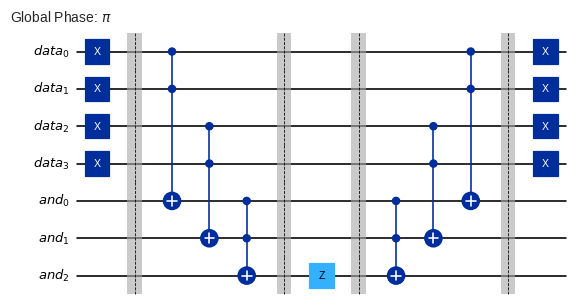

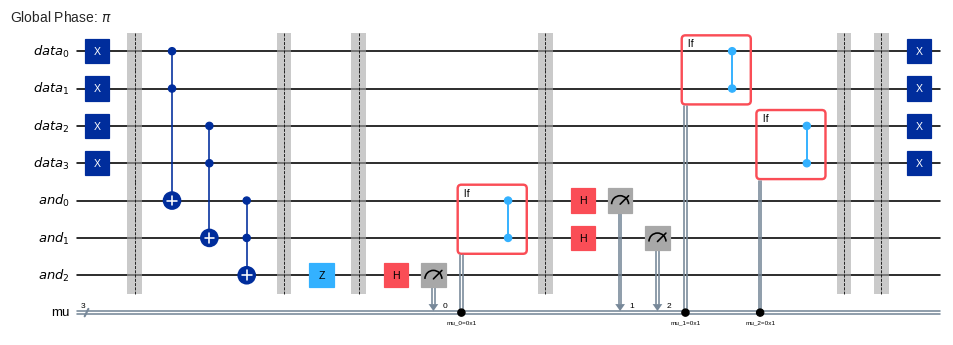

In [6]:
def apply_grover_zero_reflection(
    qc: QuantumCircuit,
    data,
    ancillas=None,
    measure_bits=None,
    implementation: str = "unitary",
    add_barriers: bool = True,
    exact_global_phase: bool = True,
) -> QuantumCircuit:
    """Apply R0 = 2|0...0><0...0| - I on the data qubits.

    The circuit is X^k -> MCZ -> X^k, plus a global phase of pi to use
    the convention |0> -> |0>, |x != 0> -> -|x>.
    """
    data = _as_list(data)
    implementation = str(implementation).lower()
    if implementation not in {"unitary", "dynamic"}:
        raise ValueError("implementation must be 'unitary' or 'dynamic'.")

    for qubit in data:
        qc.x(qubit)
    if add_barriers:
        qc.barrier()

    if implementation == "unitary":
        apply_unitary_mcz(qc, data, ancillas or [], add_barriers=add_barriers)
    else:
        apply_dynamic_mcz(qc, data, ancillas or [], measure_bits or [], add_barriers=add_barriers)

    if add_barriers:
        qc.barrier()
    for qubit in data:
        qc.x(qubit)

    if exact_global_phase:
        qc.global_phase += np.pi
    return qc


def build_grover_zero_reflection(
    num_qubits: int,
    implementation: str = "unitary",
    add_barriers: bool = True,
    exact_global_phase: bool = True,
) -> QuantumCircuit:
    """Build the reusable Grover R0 subcircuit on k data qubits."""
    k = validate_num_controls(num_qubits)
    implementation = str(implementation).lower()
    ancilla_count = mcz_ancilla_count(k)
    data = QuantumRegister(k, "data")
    regs = [data]
    anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    meas = ClassicalRegister(ancilla_count, "mu") if implementation == "dynamic" and ancilla_count else None
    if anc is not None:
        regs.append(anc)
    if meas is not None:
        regs.append(meas)

    qc = QuantumCircuit(*regs, name=f"grover_R0_{implementation}_{k}")
    apply_grover_zero_reflection(
        qc,
        data,
        ancillas=anc or [],
        measure_bits=meas or [],
        implementation=implementation,
        add_barriers=add_barriers,
        exact_global_phase=exact_global_phase,
    )
    qc.metadata = {
        "subcircuit": "grover_zero_reflection",
        "implementation": implementation,
        "num_qubits": k,
        "ancilla_count": ancilla_count,
        "exact_global_phase": bool(exact_global_phase),
    }
    return qc


def build_grover_diffusion(
    num_qubits: int,
    implementation: str = "unitary",
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Build H^k R0 H^k, the standard diffuser body used in Grover."""
    qc = build_grover_zero_reflection(
        num_qubits,
        implementation=implementation,
        add_barriers=add_barriers,
        exact_global_phase=True,
    )
    data = list(qc.qregs[0])
    diffuser = QuantumCircuit(*qc.qregs, *qc.cregs, name=f"grover_diffusion_{implementation}_{num_qubits}")
    for qubit in data:
        diffuser.h(qubit)
    if add_barriers:
        diffuser.barrier()
    diffuser.compose(qc, inplace=True)
    if add_barriers:
        diffuser.barrier()
    for qubit in data:
        diffuser.h(qubit)
    diffuser.metadata = {
        "subcircuit": "grover_diffusion",
        "implementation": implementation,
        "num_qubits": int(num_qubits),
    }
    return diffuser


# Small reusable examples for visual inspection.
grover_r0_unitary_k4 = build_grover_zero_reflection(4, "unitary", add_barriers=True)
grover_r0_dynamic_k4 = build_grover_zero_reflection(4, "dynamic", add_barriers=True)
display(pd.DataFrame([mcz_circuit_summary(grover_r0_unitary_k4), mcz_circuit_summary(grover_r0_dynamic_k4)]))
display(grover_r0_unitary_k4.draw("mpl", fold=80, scale=0.58, idle_wires=False))
display(grover_r0_dynamic_k4.draw("mpl", fold=80, scale=0.58, idle_wires=False))

### Grover R0 Resource Scaling

The resource table below analyzes the reusable `R0` subcircuit for even `k` from 2 through 40. The wrapper adds `2k` single-qubit `X` gates and two single-qubit layers to both implementations. The two-qubit resource model is otherwise inherited from the MCZ block: each CCX is counted as six native two-qubit units, and the dynamic circuit counts conditional CZ corrections in the worst case.

,num_qubits,implementation,total_qubits,num_clbits,circuit_depth_high_level,estimated_2q_depth_worst,estimated_2q_gate_count_worst,if_test_count,N_X_wrapper,N_CCX,N_measure,N_CZ_conditional_max
0,2,unitary,2,0,3,1.0,1,0,4,0,0,0
1,2,dynamic,2,0,3,1.0,1,0,4,0,0,0
2,4,unitary,7,0,7,24.0,36,0,8,6,0,0
3,4,dynamic,7,3,11,14.0,21,3,8,3,3,3
4,6,unitary,11,0,9,36.0,60,0,12,10,0,0
5,6,dynamic,11,5,15,21.0,35,5,12,5,5,5
6,8,unitary,15,0,9,36.0,84,0,16,14,0,0
7,8,dynamic,15,7,15,21.0,49,7,16,7,7,7
8,10,unitary,19,0,11,48.0,108,0,20,18,0,0
9,10,dynamic,19,9,19,28.0,63,9,20,9,9,9


N_X_wrapper         circuit_depth_high_level          \
implementation     dynamic unitary                  dynamic unitary   
num_qubits                                                            
2                        4       4                        3       3   
4                        8       8                       11       7   
6                       12      12                       15       9   
8                       16      16                       15       9   
10                      20      20                       19      11   
12                      24      24                       19      11   
14                      28      28                       19      11   
16                      32      32                       19      11   
18                      36      36                       23      13   
20                      40      40                       23      13   
22                      44      44                       23      13   
24                      48      48                       23      13   
26                      52      52                       23      13   
28                      56      56                       23      13   
30                      60      60                       23      13   
32                      64      64                       23      13   
34                      68      68                       27      15   
36                      72      72                       27      15   
38                      76      76                       27      15   
40                      80      80                       27      15   

               estimated_2q_depth_worst         estimated_2q_gate_count_worst  \
implementation                  dynamic unitary                       dynamic   
num_qubits                                                                      
2                                   1.0     1.0                             1   
4                                  14.0    24.0                            21   
6                                  21.0    36.0                            35   
8                                  21.0    36.0                            49   
10                                 28.0    48.0                            63   
12                                 28.0    48.0                            77   
14                                 28.0    48.0                            91   
16                                 28.0    48.0                           105   
18                                 35.0    60.0                           119   
20                                 35.0    60.0                           133   
22                                 35.0    60.0                           147   
24                                 35.0    60.0                           161   
26                                 35.0    60.0                           175   
28                                 35.0    60.0                           189   
30                                 35.0    60.0                           203   
32                                 35.0    60.0                           217   
34                                 42.0    72.0                           231   
36                                 42.0    72.0                           245   
38                                 42.0    72.0                           259   
40                                 42.0    72.0                           273   

                       if_test_count          
implementation unitary       dynamic unitary  
num_qubits                                    
2                    1             0       0  
4                   36             3       0  
6                   60             5       0  
8                   84             7       0  
10                 108             9       0  
12                 132            11       0  
14                 156            13       0  
16                 180            15       0  


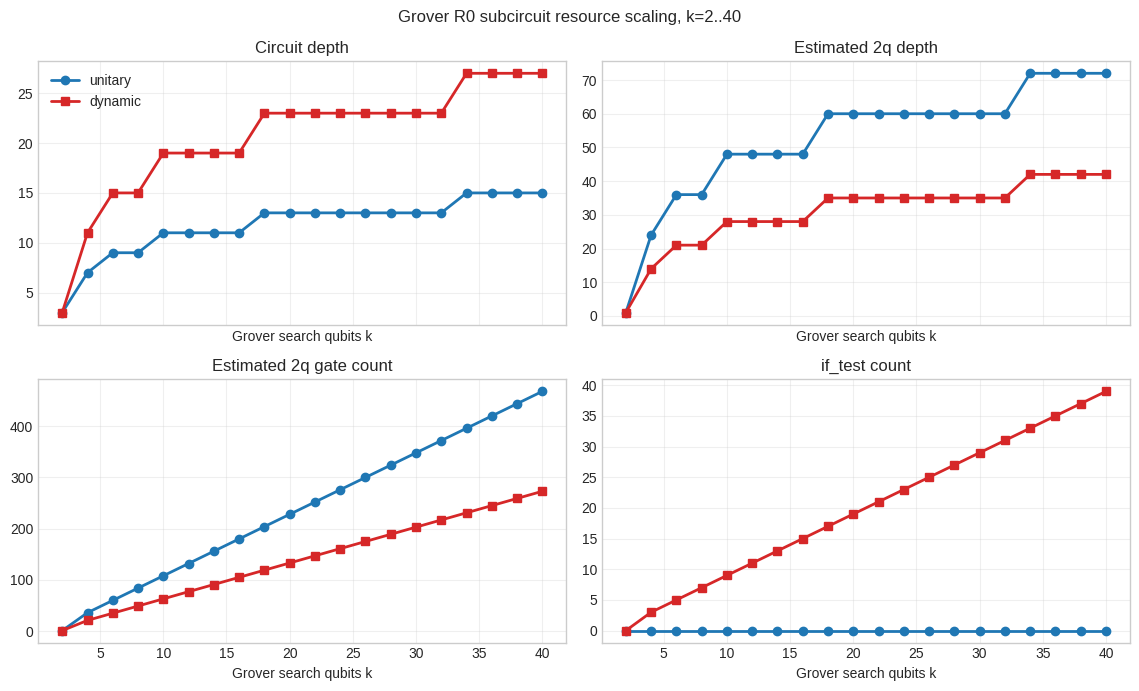

In [7]:
GROVER_R0_K_VALUES = list(range(2, 41, 2))


def grover_zero_reflection_resource_table(control_values=GROVER_R0_K_VALUES) -> pd.DataFrame:
    rows = []
    for k in control_values:
        for implementation in ["unitary", "dynamic"]:
            qc = build_grover_zero_reflection(k, implementation=implementation, add_barriers=False)
            summary = mcz_circuit_summary(qc)
            formula = mcz_resource_formula(k, implementation)

            estimated_2q_gate_count_worst = (
                formula["N_CCX"] * CCX_EQUIV_2Q_GATE_COUNT
                + formula["N_CZ_static"]
                + formula["N_CZ_conditional_max"]
            )
            estimated_2q_depth_worst = (
                formula["D_CCX"] * CCX_EQUIV_2Q_DEPTH
                + (1 if formula["N_CZ_static"] > 0 else 0)
                + formula["D_cleanup_layers"]
            )

            rows.append({
                "num_qubits": int(k),
                "implementation": implementation,
                "total_qubits": int(summary["num_qubits"]),
                "num_clbits": int(summary["num_clbits"]),
                "circuit_depth_high_level": int(summary["depth"]),
                "estimated_2q_depth_worst": float(estimated_2q_depth_worst),
                "estimated_2q_gate_count_worst": int(estimated_2q_gate_count_worst),
                "if_test_count": int(summary["if_else"]),
                "N_X_wrapper": int(2 * k),
                "N_CCX": int(formula["N_CCX"]),
                "N_measure": int(formula["N_measure"]),
                "N_CZ_static": int(formula["N_CZ_static"]),
                "N_CZ_conditional_max": int(formula["N_CZ_conditional_max"]),
                "tree_height": int(formula["tree_height"]),
                "ancilla_count": int(formula["ancilla_count"]),
            })
    return pd.DataFrame(rows)


grover_r0_resource_df = grover_zero_reflection_resource_table()
grover_r0_resource_display_columns = [
    "num_qubits",
    "implementation",
    "total_qubits",
    "num_clbits",
    "circuit_depth_high_level",
    "estimated_2q_depth_worst",
    "estimated_2q_gate_count_worst",
    "if_test_count",
    "N_X_wrapper",
    "N_CCX",
    "N_measure",
    "N_CZ_conditional_max",
]
display(grover_r0_resource_df[grover_r0_resource_display_columns])

grover_r0_resource_wide = grover_r0_resource_df.pivot_table(
    index="num_qubits",
    columns="implementation",
    values=[
        "circuit_depth_high_level",
        "estimated_2q_depth_worst",
        "estimated_2q_gate_count_worst",
        "if_test_count",
        "N_X_wrapper",
    ],
    aggfunc="first",
)
display(grover_r0_resource_wide)

GROVER_R0_RESOURCE_METRICS = [
    ("circuit_depth_high_level", "Circuit depth"),
    ("estimated_2q_depth_worst", "Estimated 2q depth"),
    ("estimated_2q_gate_count_worst", "Estimated 2q gate count"),
    ("if_test_count", "if_test count"),
]


def plot_grover_r0_resource_overlay(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.0), sharex=True)
    axes_flat = axes.ravel()
    colors = {"unitary": "tab:blue", "dynamic": "tab:red"}
    markers = {"unitary": "o", "dynamic": "s"}
    for ax, (metric, label) in zip(axes_flat, GROVER_R0_RESOURCE_METRICS):
        for implementation in ["unitary", "dynamic"]:
            sub = df[df["implementation"] == implementation].sort_values("num_qubits")
            ax.plot(
                sub["num_qubits"],
                sub[metric],
                marker=markers[implementation],
                linewidth=2.0,
                color=colors[implementation],
                label=implementation,
            )
        ax.set_title(label)
        ax.set_xlabel("Grover search qubits k")
        ax.grid(True, alpha=0.3)
    axes_flat[0].legend(frameon=False)
    fig.suptitle("Grover R0 subcircuit resource scaling, k=2..40")
    fig.tight_layout()
    plt.show()


plot_grover_r0_resource_overlay(grover_r0_resource_df)

### R0 Resource Comparison

For the Grover `R0` subcircuit, the `X^k` wrapper is identical for unitary and dynamic. It adds `2k` one-qubit gates but does not change the two-qubit count. Therefore the key tradeoff is the same as the MCZ block:

- Unitary uses the AND tree twice: compute and reverse. For `k >= 3`, the estimated two-qubit gate count is approximately `12(k-1)` under the `CCX = 6 two-qubit units` model.
- Dynamic uses the AND tree once, then measurement-uncomputes. For `k >= 3`, the worst-case estimated two-qubit gate count is approximately `7(k-1)`: `6(k-1)` from CCX plus up to `k-1` conditional CZ corrections.
- Dynamic reduces estimated two-qubit depth from roughly `12 ceil(log2(k))` to roughly `7 ceil(log2(k))`, but introduces `k-1` mid-circuit measurements and `k-1` `if_test` correction blocks.
- In a full Grover diffuser, adding the outer `H^k` layers changes only one-qubit resources; the two-qubit comparison remains the same.

## Full Grover Circuit

This section builds a full Grover circuit from the reusable reflection blocks:

1. Prepare `|s> = H^k |0...0>`.
2. Apply the marked-state phase oracle `O_w = I - 2|w><w|`.
3. Apply the diffuser `D = H^k R0 H^k`.
4. Repeat the Grover iteration.
5. Measure the data register.

Important implementation point: the dynamic reflection measures the AND-tree ancillas. A repeated Grover circuit cannot safely reuse those measured ancillas unless we add a reset/reuse subroutine and validate it. The builder below therefore uses fresh dynamic workspace per reflection. That is correct and simple, but it makes the dynamic qubit count grow with the number of Grover iterations. Before a hardware Grover experiment, the next useful sub-step is to implement and test a `reset`-based workspace-reuse version.

In [7]:
def normalize_marked_state(marked_state, num_qubits: int) -> str:
    """Return a q0..q{k-1} bitstring. Default marks |11...1>."""
    k = validate_num_controls(num_qubits)
    if marked_state is None:
        return "1" * k
    if isinstance(marked_state, int):
        if marked_state < 0 or marked_state >= (1 << k):
            raise ValueError(f"marked_state integer must be in [0, {1 << k}).")
        return format(marked_state, f"0{k}b")
    bits = str(marked_state).replace("_", "").replace(" ", "")
    if len(bits) != k or any(bit not in "01" for bit in bits):
        raise ValueError(f"marked_state must be a {k}-bit string or an integer.")
    return bits


def optimal_grover_iterations(num_qubits: int, num_marked: int = 1) -> int:
    """Nearest integer to the single-register Grover optimum."""
    k = validate_num_controls(num_qubits)
    marked = int(num_marked)
    if marked <= 0 or marked >= (1 << k):
        raise ValueError("num_marked must be between 1 and 2^k - 1.")
    theta = math.asin(math.sqrt(marked / (1 << k)))
    return max(1, int(round(math.pi / (4.0 * theta) - 0.5)))


def apply_grover_marked_oracle(
    qc: QuantumCircuit,
    data,
    marked_state=None,
    ancillas=None,
    measure_bits=None,
    implementation: str = "unitary",
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Apply O_w = I - 2|w><w| for a computational-basis marked state."""
    data = _as_list(data)
    bits = normalize_marked_state(marked_state, len(data))
    implementation = str(implementation).lower()
    if implementation not in {"unitary", "dynamic"}:
        raise ValueError("implementation must be 'unitary' or 'dynamic'.")

    zero_positions = [index for index, bit in enumerate(bits) if bit == "0"]
    for index in zero_positions:
        qc.x(data[index])
    if add_barriers and zero_positions:
        qc.barrier()

    if implementation == "unitary":
        apply_unitary_mcz(qc, data, ancillas or [], add_barriers=add_barriers)
    else:
        apply_dynamic_mcz(qc, data, ancillas or [], measure_bits or [], add_barriers=add_barriers)

    if add_barriers and zero_positions:
        qc.barrier()
    for index in zero_positions:
        qc.x(data[index])
    return qc


def build_grover_marked_oracle(
    num_qubits: int,
    marked_state=None,
    implementation: str = "unitary",
    add_barriers: bool = True,
) -> QuantumCircuit:
    k = validate_num_controls(num_qubits)
    implementation = str(implementation).lower()
    ancilla_count = mcz_ancilla_count(k)
    data = QuantumRegister(k, "data")
    regs = [data]
    anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    meas = ClassicalRegister(ancilla_count, "mu") if implementation == "dynamic" and ancilla_count else None
    if anc is not None:
        regs.append(anc)
    if meas is not None:
        regs.append(meas)
    qc = QuantumCircuit(*regs, name=f"grover_oracle_{implementation}_{k}")
    apply_grover_marked_oracle(qc, data, marked_state, anc or [], meas or [], implementation, add_barriers)
    qc.metadata = {
        "subcircuit": "grover_marked_oracle",
        "implementation": implementation,
        "num_qubits": k,
        "marked_state": normalize_marked_state(marked_state, k),
        "ancilla_count": ancilla_count,
    }
    return qc


def build_full_grover_circuit(
    num_qubits: int,
    marked_state=None,
    num_iterations: int | None = None,
    implementation: str = "unitary",
    measure: bool = True,
    add_barriers: bool = True,
    max_constructed_iterations: int = 32,
) -> QuantumCircuit:
    """Build a full Grover search circuit.

    Dynamic circuits use fresh workspace per oracle/diffuser reflection. This is
    correct without reset, but expensive in qubits for many iterations.
    """
    k = validate_num_controls(num_qubits)
    marked_bits = normalize_marked_state(marked_state, k)
    implementation = str(implementation).lower()
    if implementation not in {"unitary", "dynamic"}:
        raise ValueError("implementation must be 'unitary' or 'dynamic'.")
    iterations = optimal_grover_iterations(k) if num_iterations is None else int(num_iterations)
    if iterations < 0:
        raise ValueError("num_iterations must be non-negative.")
    if iterations > max_constructed_iterations:
        raise ValueError(
            f"Refusing to materialize {iterations} Grover iterations. "
            "Use grover_full_resource_table for large-k resource estimates."
        )

    ancilla_count = mcz_ancilla_count(k)
    data = QuantumRegister(k, "data")
    regs = [data]

    shared_anc = None
    dynamic_workspaces = []
    if implementation == "unitary" and ancilla_count:
        shared_anc = QuantumRegister(ancilla_count, "and")
        regs.append(shared_anc)
    elif implementation == "dynamic" and ancilla_count:
        for iteration in range(iterations):
            oracle_anc = QuantumRegister(ancilla_count, f"ora_and_{iteration}")
            oracle_mu = ClassicalRegister(ancilla_count, f"ora_mu_{iteration}")
            diffuser_anc = QuantumRegister(ancilla_count, f"dif_and_{iteration}")
            diffuser_mu = ClassicalRegister(ancilla_count, f"dif_mu_{iteration}")
            regs.extend([oracle_anc, oracle_mu, diffuser_anc, diffuser_mu])
            dynamic_workspaces.append((oracle_anc, oracle_mu, diffuser_anc, diffuser_mu))

    out = ClassicalRegister(k, "out") if measure else None
    if out is not None:
        regs.append(out)

    qc = QuantumCircuit(*regs, name=f"grover_{implementation}_{k}_r{iterations}")
    for qubit in data:
        qc.h(qubit)
    if add_barriers:
        qc.barrier()

    for iteration in range(iterations):
        if implementation == "unitary":
            anc = shared_anc or []
            apply_grover_marked_oracle(qc, data, marked_bits, anc, [], "unitary", add_barriers)
            if add_barriers:
                qc.barrier()
            for qubit in data:
                qc.h(qubit)
            if add_barriers:
                qc.barrier()
            apply_grover_zero_reflection(qc, data, anc, [], "unitary", add_barriers, exact_global_phase=True)
            if add_barriers:
                qc.barrier()
            for qubit in data:
                qc.h(qubit)
        else:
            if ancilla_count:
                oracle_anc, oracle_mu, diffuser_anc, diffuser_mu = dynamic_workspaces[iteration]
            else:
                oracle_anc = oracle_mu = diffuser_anc = diffuser_mu = []
            apply_grover_marked_oracle(qc, data, marked_bits, oracle_anc, oracle_mu, "dynamic", add_barriers)
            if add_barriers:
                qc.barrier()
            for qubit in data:
                qc.h(qubit)
            if add_barriers:
                qc.barrier()
            apply_grover_zero_reflection(qc, data, diffuser_anc, diffuser_mu, "dynamic", add_barriers, exact_global_phase=True)
            if add_barriers:
                qc.barrier()
            for qubit in data:
                qc.h(qubit)

        if add_barriers and iteration + 1 < iterations:
            qc.barrier()

    if out is not None:
        for index, qubit in enumerate(data):
            qc.measure(qubit, out[index])

    qc.metadata = {
        "algorithm": "grover_search",
        "implementation": implementation,
        "num_qubits": k,
        "marked_state": marked_bits,
        "num_iterations": iterations,
        "dynamic_workspace_mode": "fresh_per_reflection" if implementation == "dynamic" else "shared_reversible",
    }
    return qc


# Small executable examples. Larger k should use the analytic resource table below.
grover_example_k = 4
grover_example_iterations = optimal_grover_iterations(grover_example_k)
grover_unitary_example = build_full_grover_circuit(grover_example_k, num_iterations=grover_example_iterations, implementation="unitary", add_barriers=False)
grover_dynamic_example = build_full_grover_circuit(grover_example_k, num_iterations=grover_example_iterations, implementation="dynamic", add_barriers=False)
display(pd.DataFrame([mcz_circuit_summary(grover_unitary_example), mcz_circuit_summary(grover_dynamic_example)]))

,name,num_qubits,num_clbits,depth,ccx,cz,z,h,measure,if_else
0,grover_unitary_4_r3,7,4,44,36,0,6,28,4,0
1,grover_dynamic_4_r3,22,22,68,18,0,6,46,22,18


### Full Grover Resource Scaling

The table uses the optimal iteration count for one marked item:

\[
r \approx \mathrm{round}\left(\frac{\pi}{4\arcsin(1/\sqrt{2^k})} - \frac{1}{2}\right).
\]

For `k=40`, this is already on the order of one million Grover iterations, so the full circuit is not materialized. The resource comparison is analytic and reuses the same high-level model used for MCZ and `R0`.

,num_qubits,implementation,optimal_iterations,total_qubits_fresh_dynamic,workspace_qubits,circuit_depth_high_level_est,estimated_2q_depth_worst,estimated_2q_gate_count_worst,if_test_count,dynamic_mid_measurements,N_H_total,N_X_wrapper_total
0,2,unitary,1,2,0,8,2.0,2,0,0,6,4
1,2,dynamic,1,2,0,8,2.0,2,0,0,6,4
2,4,unitary,3,7,3,44,144.0,216,0,0,28,24
3,4,dynamic,3,22,18,68,84.0,126,18,18,28,24
4,6,unitary,6,11,5,110,432.0,720,0,0,78,72
5,6,dynamic,6,66,60,182,252.0,420,60,60,78,72
6,8,unitary,12,15,7,218,864.0,2016,0,0,200,192
7,8,dynamic,12,176,168,362,504.0,1176,168,168,200,192
8,10,unitary,25,19,9,552,2400.0,5400,0,0,510,500
9,10,dynamic,25,460,450,952,1400.0,3150,450,450,510,500


circuit_depth_high_level_est            \
implementation                      dynamic   unitary   
num_qubits                                              
2                                         8         8   
4                                        68        44   
6                                       182       110   
8                                       362       218   
10                                      952       552   
12                                     1902      1102   
14                                     3802      2202   
16                                     7640      4424   
18                                    18494     10454   
20                                    36986     20906   
22                                    73970     41810   
24                                   147938     83618   
26                                   295920    167260   
28                                   591884    334544   
30                                  1183812    669112   
32                                  2367668   1338248   
34                                  5558924   3088292   
36                                 11117900   6176612   
38                                 22235798  12353222   
40                                 44471648  24706472   

               estimated_2q_depth_worst               \
implementation                  dynamic      unitary   
num_qubits                                             
2                                   2.0          2.0   
4                                  84.0        144.0   
6                                 252.0        432.0   
8                                 504.0        864.0   
10                               1400.0       2400.0   
12                               2800.0       4800.0   
14                               5600.0       9600.0   
16                              11256.0      19296.0   
18                              28140.0      48240.0   
20                              56280.0      96480.0   
22                             112560.0     192960.0   
24                             225120.0     385920.0   
26                             450310.0     771960.0   
28                             900690.0    1544040.0   
30                            1801450.0    3088200.0   
32                            3602970.0    6176520.0   
34                            8647212.0   14823792.0   
36                           17294508.0   29647728.0   
38                           34589016.0   59295456.0   
40                           69178116.0  118591056.0   

               estimated_2q_gate_count_worst            if_test_count          \
implementation                       dynamic    unitary       dynamic unitary   
num_qubits                                                                      
2                                          2          2             0       0   
4                                        126        216            18       0   
6                                        420        720            60       0   
8                                       1176       2016           168       0   
10                                      3150       5400           450       0   
12                                      7700      13200          1100       0   
14                                     18200      31200          2600       0   
16                                     42210      72360          6030       0   
18                                     95676     164016         13668       0   
20                                    213864     366624         30552       0   
22                                    472752     810432         67536       0   
24                                   1035552    1775232        147936       0   
26                                   2251550    3859800        321650       0   
28                                   4863726    8337816        694818       0   
30                                  1

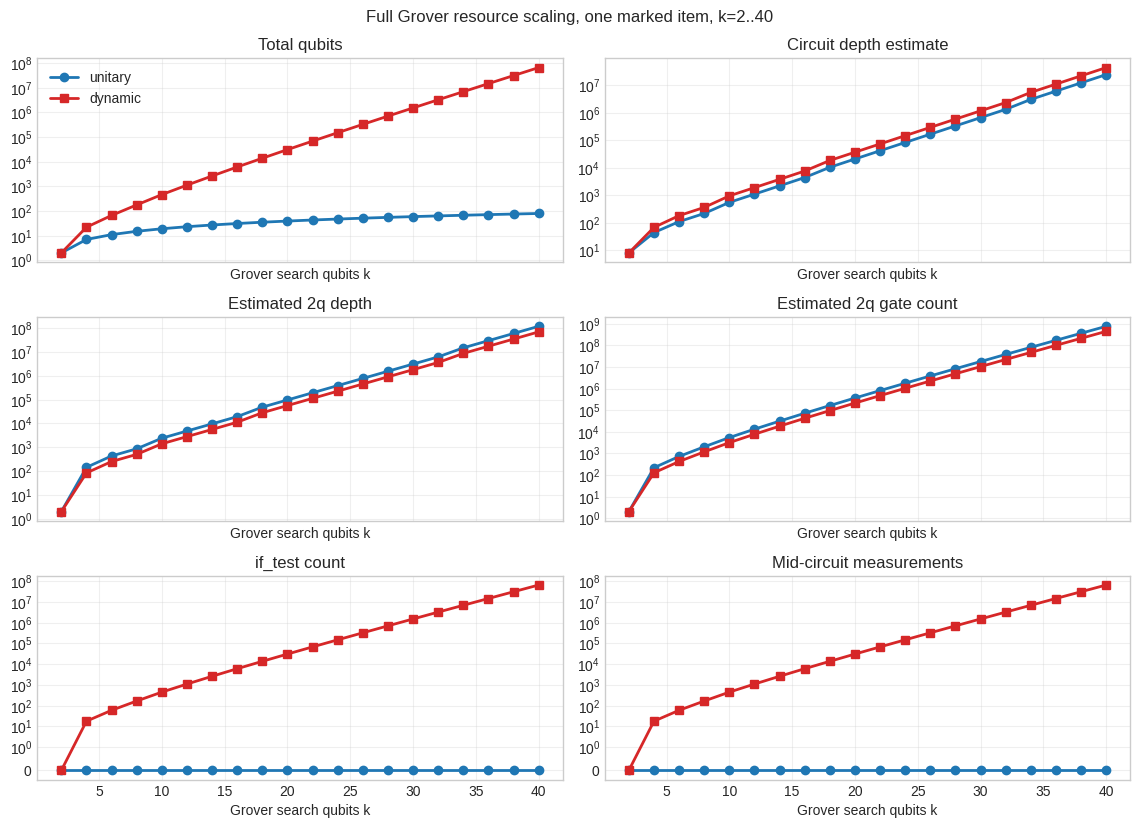

In [8]:
FULL_GROVER_K_VALUES = list(range(2, 41, 2))
FULL_GROVER_DEFAULT_MARKED_STATE = None  # None means |11...1>, so oracle X-wrapper cost is zero.


def grover_full_resource_table(control_values=FULL_GROVER_K_VALUES, marked_state=FULL_GROVER_DEFAULT_MARKED_STATE) -> pd.DataFrame:
    rows = []
    for k in control_values:
        marked_bits = normalize_marked_state(marked_state, k)
        marked_zero_count = marked_bits.count("0")
        iterations = optimal_grover_iterations(k)
        anc = mcz_ancilla_count(k)
        for implementation in ["unitary", "dynamic"]:
            formula = mcz_resource_formula(k, implementation)
            mcz_2q_count = (
                formula["N_CCX"] * CCX_EQUIV_2Q_GATE_COUNT
                + formula["N_CZ_static"]
                + formula["N_CZ_conditional_max"]
            )
            mcz_2q_depth = (
                formula["D_CCX"] * CCX_EQUIV_2Q_DEPTH
                + (1 if formula["N_CZ_static"] > 0 else 0)
                + formula["D_cleanup_layers"]
            )

            oracle_x_depth = 2 if marked_zero_count else 0
            oracle_mcz_depth = build_unitary_mcz(k, add_barriers=False).depth() if implementation == "unitary" else build_dynamic_mcz(k, add_barriers=False).depth()
            oracle_depth = oracle_mcz_depth + oracle_x_depth
            r0_depth = build_grover_zero_reflection(k, implementation=implementation, add_barriers=False).depth()
            diffuser_depth = r0_depth + 2  # H^k before and after R0.
            iteration_depth = oracle_depth + diffuser_depth

            if implementation == "unitary":
                workspace_qubits = anc
                dynamic_mid_measurements = 0
                if_test_count = 0
            else:
                workspace_qubits = 2 * iterations * anc
                dynamic_mid_measurements = 2 * iterations * anc
                if_test_count = 2 * iterations * formula["N_CZ_conditional_max"]

            rows.append({
                "num_qubits": int(k),
                "implementation": implementation,
                "marked_state": marked_bits,
                "optimal_iterations": int(iterations),
                "total_qubits_fresh_dynamic": int(k + workspace_qubits),
                "workspace_qubits": int(workspace_qubits),
                "final_measurements": int(k),
                "dynamic_mid_measurements": int(dynamic_mid_measurements),
                "circuit_depth_high_level_est": int(1 + iterations * iteration_depth + 1),
                "estimated_2q_depth_worst": float(iterations * 2 * mcz_2q_depth),
                "estimated_2q_gate_count_worst": int(iterations * 2 * mcz_2q_count),
                "if_test_count": int(if_test_count),
                "N_H_total": int(k + iterations * 2 * k),
                "N_X_wrapper_total": int(iterations * (2 * marked_zero_count + 2 * k)),
                "N_CCX_total": int(iterations * 2 * formula["N_CCX"]),
                "N_measure_total": int(dynamic_mid_measurements + k),
            })
    return pd.DataFrame(rows)


grover_full_resource_df = grover_full_resource_table()
grover_full_display_columns = [
    "num_qubits",
    "implementation",
    "optimal_iterations",
    "total_qubits_fresh_dynamic",
    "workspace_qubits",
    "circuit_depth_high_level_est",
    "estimated_2q_depth_worst",
    "estimated_2q_gate_count_worst",
    "if_test_count",
    "dynamic_mid_measurements",
    "N_H_total",
    "N_X_wrapper_total",
]
display(grover_full_resource_df[grover_full_display_columns])

grover_full_resource_wide = grover_full_resource_df.pivot_table(
    index="num_qubits",
    columns="implementation",
    values=[
        "optimal_iterations",
        "total_qubits_fresh_dynamic",
        "circuit_depth_high_level_est",
        "estimated_2q_depth_worst",
        "estimated_2q_gate_count_worst",
        "if_test_count",
    ],
    aggfunc="first",
)
display(grover_full_resource_wide)

FULL_GROVER_RESOURCE_METRICS = [
    ("total_qubits_fresh_dynamic", "Total qubits"),
    ("circuit_depth_high_level_est", "Circuit depth estimate"),
    ("estimated_2q_depth_worst", "Estimated 2q depth"),
    ("estimated_2q_gate_count_worst", "Estimated 2q gate count"),
    ("if_test_count", "if_test count"),
    ("dynamic_mid_measurements", "Mid-circuit measurements"),
]


def plot_full_grover_resource_overlay(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(3, 2, figsize=(11.5, 8.4), sharex=True)
    axes_flat = axes.ravel()
    colors = {"unitary": "tab:blue", "dynamic": "tab:red"}
    markers = {"unitary": "o", "dynamic": "s"}
    for ax, (metric, label) in zip(axes_flat, FULL_GROVER_RESOURCE_METRICS):
        for implementation in ["unitary", "dynamic"]:
            sub = df[df["implementation"] == implementation].sort_values("num_qubits")
            ax.plot(
                sub["num_qubits"],
                sub[metric],
                marker=markers[implementation],
                linewidth=2.0,
                color=colors[implementation],
                label=implementation,
            )
        ax.set_title(label)
        ax.set_xlabel("Grover search qubits k")
        ax.set_yscale("symlog", linthresh=1)
        ax.grid(True, alpha=0.3)
    axes_flat[0].legend(frameon=False)
    fig.suptitle("Full Grover resource scaling, one marked item, k=2..40")
    fig.tight_layout()
    plt.show()


plot_full_grover_resource_overlay(grover_full_resource_df)

### Full Grover Resource Takeaway

For a single marked item, full Grover quickly becomes dominated by the optimal iteration count, which grows as `O(2^(k/2))`. The dynamic reflection still reduces the two-qubit work per reflection, so the dynamic full circuit has lower two-qubit count and depth under this model. However, without reset/reuse, a dynamic implementation consumes fresh measured workspace for every oracle and diffuser reflection. That makes the dynamic qubit count scale as `2 r (k-1)` extra qubits, where `r` is the Grover iteration count.

So the next engineering sub-step before a realistic hardware Grover run is clear: implement a reset/reuse version of the dynamic reflection, verify that it remains correct across repeated oracle/diffuser calls, and add reset latency/error to the resource model.

## Noise Environments

The first noise model mirrors the setup from Problem 3: simple Aer noise channels for depolarizing error, readout error, and thermal relaxation. This intentionally avoids `AerSimulator.from_backend()` for large backends, because that can instantiate a full backend-sized simulation.

The default model applies noise directly to high-level `ccx` and `cz` operations. This is not a final hardware model; it is a controllable environment for comparing the two algorithmic structures before moving to backend-specific transpilation.


In [6]:
@dataclass(frozen=True)
class NoiseConfig:
    name: str
    include_depolarizing: bool = False
    include_readout: bool = False
    include_thermal: bool = False
    p_1q: float = 1.0e-4
    p_cz: float = 3.0e-3
    p_ccx: float = 2.0e-2
    p_readout: float = 2.0e-2
    t1: float = 200_000.0       # ns
    t2: float = 150_000.0       # ns
    t_1q: float = 50.0          # ns
    t_2q: float = 300.0         # ns
    t_3q: float = 1_000.0       # ns
    t_meas: float = 1_000.0     # ns


def _compose_errors(errors):
    if not errors:
        return None
    combined = errors[0]
    for error in errors[1:]:
        combined = combined.compose(error)
    return combined


def _thermal_n_qubit_error(t1: float, t2: float, gate_time: float, n_qubits: int):
    error = thermal_relaxation_error(t1, t2, gate_time)
    for _ in range(n_qubits - 1):
        error = error.tensor(thermal_relaxation_error(t1, t2, gate_time))
    return error


def build_mcz_noise_model(config: NoiseConfig) -> NoiseModel | None:
    if not (config.include_depolarizing or config.include_readout or config.include_thermal):
        return None

    noise_model = NoiseModel()

    one_qubit_errors = []
    two_qubit_errors = []
    three_qubit_errors = []

    if config.include_depolarizing:
        one_qubit_errors.append(depolarizing_error(min(max(config.p_1q, 0.0), 0.75 - 1e-12), 1))
        two_qubit_errors.append(depolarizing_error(min(max(config.p_cz, 0.0), 15 / 16 - 1e-12), 2))
        three_qubit_errors.append(depolarizing_error(min(max(config.p_ccx, 0.0), 63 / 64 - 1e-12), 3))

    if config.include_thermal:
        t2 = min(config.t2, 2.0 * config.t1)
        one_qubit_errors.append(thermal_relaxation_error(config.t1, t2, config.t_1q))
        two_qubit_errors.append(_thermal_n_qubit_error(config.t1, t2, config.t_2q, 2))
        three_qubit_errors.append(_thermal_n_qubit_error(config.t1, t2, config.t_3q, 3))

    one_qubit_error = _compose_errors(one_qubit_errors)
    two_qubit_error = _compose_errors(two_qubit_errors)
    three_qubit_error = _compose_errors(three_qubit_errors)

    if one_qubit_error is not None:
        noise_model.add_all_qubit_quantum_error(one_qubit_error, ["h", "x", "sx", "id", "z"])
    if two_qubit_error is not None:
        noise_model.add_all_qubit_quantum_error(two_qubit_error, ["cz", "cx"])
    if three_qubit_error is not None:
        noise_model.add_all_qubit_quantum_error(three_qubit_error, ["ccx"])

    if config.include_readout:
        p = min(max(config.p_readout, 0.0), 0.5)
        noise_model.add_all_qubit_readout_error(ReadoutError([[1 - p, p], [p, 1 - p]]))

    return noise_model


NOISE_CONFIGS = {
    "ideal": NoiseConfig("ideal"),
    "depolarizing": NoiseConfig("depolarizing", include_depolarizing=True),
    "readout": NoiseConfig("readout", include_readout=True),
    "thermal": NoiseConfig("thermal", include_thermal=True),
    "combined": NoiseConfig("combined", include_depolarizing=True, include_readout=True, include_thermal=True),
}

print("Noise configs:", list(NOISE_CONFIGS))


Noise configs: ['ideal', 'depolarizing', 'readout', 'thermal', 'combined']


## Optional Fake-Backend Calibration

This cell extracts median calibration-like parameters from an IBM fake backend and converts them into a `NoiseConfig`. It is optional and local-only: it does not submit jobs or require hardware access.


In [7]:
def _backend_name(backend) -> str:
    name = getattr(backend, "name", None)
    return name() if callable(name) else str(name)


def _median_backend_value(backend, op_names, attr: str, default: float) -> float:
    values = []
    target = getattr(backend, "target", None)
    if target is None:
        return default
    for op_name in op_names:
        if op_name not in target.operation_names:
            continue
        for _, props in target[op_name].items():
            if props is None:
                continue
            value = getattr(props, attr, None)
            if value is not None:
                values.append(float(value))
    return float(np.median(values)) if values else default


def _median_readout_error(backend, default: float = 0.02) -> float:
    values = []
    target = getattr(backend, "target", None)
    if target is None or "measure" not in target.operation_names:
        return default
    for _, props in target["measure"].items():
        if props is not None and props.error is not None:
            values.append(float(props.error))
    return float(np.median(values)) if values else default


def noise_config_from_fake_backend(backend, name: str | None = None) -> NoiseConfig:
    twoq_error = _median_backend_value(backend, ["cz", "ecr", "cx"], "error", 0.006)
    twoq_duration = _median_backend_value(backend, ["cz", "ecr", "cx"], "duration", 300e-9) * 1e9
    meas_duration = _median_backend_value(backend, ["measure"], "duration", 1_000e-9) * 1e9
    readout_error = _median_readout_error(backend, 0.02)

    # A CCX is not native on IBM hardware. This rough value treats it as several two-qubit entangling gates.
    p_ccx = min(0.25, 6.0 * twoq_error)

    return NoiseConfig(
        name=name or f"calibrated_{_backend_name(backend)}",
        include_depolarizing=True,
        include_readout=True,
        include_thermal=True,
        p_1q=1.0e-4,
        p_cz=twoq_error,
        p_ccx=p_ccx,
        p_readout=readout_error,
        t_2q=twoq_duration,
        t_3q=6.0 * twoq_duration,
        t_meas=meas_duration,
    )


def try_load_fake_backend(name: str = "FakeBrisbane"):
    try:
        from qiskit_ibm_runtime import fake_provider as fake_provider
        cls = getattr(fake_provider, name)
        return cls()
    except Exception as exc:
        print(f"Could not load {name}: {type(exc).__name__}: {exc}")
        return None


fake_backend = try_load_fake_backend("FakeBrisbane")
if fake_backend is not None:
    fake_noise_config = noise_config_from_fake_backend(fake_backend)
    NOISE_CONFIGS["fake_backend_calibrated"] = fake_noise_config
    display(pd.DataFrame([fake_noise_config.__dict__]))
else:
    print("Continuing with built-in local noise configs only.")


,name,include_depolarizing,include_readout,include_thermal,p_1q,p_cz,p_ccx,p_readout,t1,t2,t_1q,t_2q,t_3q,t_meas
0,calibrated_fake_brisbane,True,True,True,0.0001,0.007719,0.046316,0.02002,200000.0,150000.0,50.0,660.0,3960.0,1300.0


## Budget Helpers

This is a coarse first-pass budget. It is meant to compare algorithmic structure, not to replace backend-specific transpiled accounting.


In [8]:
def lambda_from_error_probability(probability: float) -> float:
    probability = min(max(float(probability), 0.0), 1.0 - 1e-12)
    return float(-math.log(1.0 - probability))


def mcz_lambda_rates(config: NoiseConfig) -> dict:
    return {
        "lambda_1q": lambda_from_error_probability(config.p_1q if config.include_depolarizing else 0.0),
        "lambda_cz": lambda_from_error_probability(config.p_cz if config.include_depolarizing else 0.0),
        "lambda_ccx": lambda_from_error_probability(config.p_ccx if config.include_depolarizing else 0.0),
        "lambda_meas": lambda_from_error_probability(config.p_readout if config.include_readout else 0.0),
    }


def mcz_lambda_budget(num_controls: int, implementation: str, config: NoiseConfig) -> dict:
    res = mcz_resource_formula(num_controls, implementation)
    rates = mcz_lambda_rates(config)
    lam = (
        res["N_CCX"] * rates["lambda_ccx"]
        + (res["N_CZ_static"] + res["N_CZ_conditional_max"]) * rates["lambda_cz"]
        + res["N_X_meas"] * rates["lambda_meas"]
    )
    return {**res, **rates, "lambda_total_worst": lam, "F_bound_worst": math.exp(-lam)}


def mcz_budget_table(control_values: Iterable[int], noise_label: str = "combined") -> pd.DataFrame:
    config = NOISE_CONFIGS[noise_label]
    rows = []
    for k in control_values:
        for implementation in ["unitary", "dynamic"]:
            rows.append({"noise_model": noise_label, **mcz_lambda_budget(k, implementation, config)})
    return pd.DataFrame(rows)


budget_df = mcz_budget_table([2, 3, 4, 5, 6, 7], noise_label="combined")
display(budget_df[["num_controls", "implementation", "N_gate_total_worst", "N_measure", "N_CCX", "N_CZ_conditional_max", "D_CCX", "t_idle_2q_units", "estimated_wall_time_2q_units", "lambda_total_worst", "F_bound_worst"]])


,num_controls,implementation,N_gate_total_worst,N_measure,N_CCX,N_CZ_conditional_max,D_CCX,t_idle_2q_units,estimated_wall_time_2q_units,lambda_total_worst,F_bound_worst
0,2,unitary,1,0,0,0,0,0.0,1.0,0.003005,0.997000
1,2,dynamic,1,0,0,0,0,0.0,1.0,0.003005,0.997000
2,3,unitary,5,0,4,0,4,0.0,24.0,0.080811,0.922368
3,3,dynamic,5,2,2,2,2,10.0,24.0,0.086820,0.916842
4,4,unitary,7,0,6,0,4,0.0,24.0,0.121216,0.885842
5,4,dynamic,7,3,3,3,2,10.0,24.0,0.130230,0.877894
6,5,unitary,9,0,8,0,6,0.0,36.0,0.161622,0.850763
7,5,dynamic,9,4,4,4,3,15.0,36.0,0.173640,0.840600
8,6,unitary,11,0,10,0,6,0.0,36.0,0.202027,0.817073
9,6,dynamic,11,5,5,5,3,15.0,36.0,0.217050,0.804890


## Probabilistic Echo Experiments

The default probabilistic sweep runs through `k = 7`, because exact local noisy simulation grows exponentially with the echo-test qubit count. The reported number is `P(decoded output = 0...0)`, not process fidelity or average gate fidelity.


In [ ]:
from pathlib import Path
from datetime import datetime, timezone

PROBLEM4_LOG_DIR = Path("log/problem4")
PROBLEM4_LOG_DIR.mkdir(parents=True, exist_ok=True)
PROBABILITY_LOG_PATH = PROBLEM4_LOG_DIR / "mcz_probabilistic_echo_k3_16.csv"
FIDELITY_LOG_PATH = PROBLEM4_LOG_DIR / "mcz_pauli_fidelity_k3_16_samples48.csv"


def _utc_timestamp() -> str:
    return datetime.now(timezone.utc).isoformat()


def _csv_safe_row(row: dict) -> dict:
    safe = {}
    for key, value in row.items():
        if isinstance(value, (dict, list, tuple)):
            continue
        if isinstance(value, np.generic):
            value = value.item()
        safe[key] = value
    return safe


def append_experiment_log_row(log_path: Path, row: dict) -> None:
    log_path = Path(log_path)
    log_path.parent.mkdir(parents=True, exist_ok=True)
    safe = _csv_safe_row(row)
    header = not log_path.exists() or log_path.stat().st_size == 0
    pd.DataFrame([safe]).to_csv(log_path, mode="a", header=header, index=False)


def load_experiment_log(log_path: Path) -> pd.DataFrame:
    log_path = Path(log_path)
    if not log_path.exists() or log_path.stat().st_size == 0:
        return pd.DataFrame()
    return pd.read_csv(log_path)


def _logged_key(row: dict, key_columns: Iterable[str]) -> tuple:
    return tuple(row.get(column) for column in key_columns)


def _existing_log_keys(log_path: Path, key_columns: Iterable[str]) -> set[tuple]:
    df = load_experiment_log(log_path)
    if df.empty:
        return set()
    missing = [column for column in key_columns if column not in df.columns]
    if missing:
        return set()
    return {tuple(record[column] for column in key_columns) for record in df.to_dict("records")}


def run_mcz_probabilistic_sweep(
    control_values: Iterable[int],
    implementations: Iterable[str] = ("unitary", "dynamic"),
    noise_labels: Iterable[str] = ("ideal", "depolarizing", "readout", "thermal", "combined"),
    shots: int = DEFAULT_SHOTS,
    seed: int = SEED,
    log_path: Path | None = None,
    resume: bool = True,
) -> pd.DataFrame:
    rows = []
    key_columns = ["experiment", "noise_model", "num_controls", "implementation", "shots", "seed"]
    existing_keys = _existing_log_keys(log_path, key_columns) if log_path is not None and resume else set()
    for noise_label in noise_labels:
        config = NOISE_CONFIGS[noise_label]
        noise_model = build_mcz_noise_model(config)
        for k in control_values:
            for implementation in implementations:
                base_row = {
                    "experiment": "probabilistic_echo_shared_workspace",
                    "noise_model": noise_label,
                    "num_controls": int(k),
                    "implementation": implementation,
                    "shots": int(shots),
                    "seed": int(seed),
                }
                if _logged_key(base_row, key_columns) in existing_keys:
                    print(f"skip logged probability {noise_label:10s} {implementation:7s} k={int(k):2d}", flush=True)
                    continue
                row = run_mcz_echo(k, implementation=implementation, noise_model=noise_model, shots=shots, seed=seed)
                budget = mcz_lambda_budget(k, implementation, config)
                decoded_success = row["echo_success_probability"]
                output_row = {
                    **base_row,
                    "timestamp_utc": _utc_timestamp(),
                    "decoded_success_probability": decoded_success,
                    "decoded_failure_probability": 1.0 - decoded_success,
                    "num_qubits_in_echo": row["num_qubits"],
                    "num_clbits_in_echo": row["num_clbits"],
                    "ccx_in_echo": row["ccx"],
                    "cz_in_echo": row["cz"],
                    "measure_in_echo": row["measure"],
                    "if_else_in_echo": row["if_else"],
                    "candidate_N_gate_total_worst": budget["N_gate_total_worst"],
                    "candidate_N_CCX": budget["N_CCX"],
                    "candidate_N_X_meas": budget["N_X_meas"],
                    "candidate_N_CZ_conditional_max": budget["N_CZ_conditional_max"],
                    "candidate_N_measure": budget["N_measure"],
                    "candidate_D_CCX": budget["D_CCX"],
                    "candidate_t_idle_2q_units": budget["t_idle_2q_units"],
                    "candidate_estimated_wall_time_2q_units": budget["estimated_wall_time_2q_units"],
                    "budget_F_bound_worst": budget["F_bound_worst"],
                    "budget_lambda_total_worst": budget["lambda_total_worst"],
                }
                rows.append(output_row)
                if log_path is not None:
                    append_experiment_log_row(log_path, output_row)
                print(
                    f"{noise_label:10s} {implementation:7s} "
                    f"k={int(k):2d} P_decode={decoded_success:.4f} "
                    f"qubits={row['num_qubits']:2d} N_CCX={budget['N_CCX']:2d} meas={budget['N_X_meas']:2d}",
                    flush=True,
                )
    new_df = pd.DataFrame(rows)
    if log_path is not None:
        return load_experiment_log(log_path)
    return new_df


# Backward-compatible alias for older cells/users that still call the echo name.
run_mcz_echo_sweep = run_mcz_probabilistic_sweep

CONTROL_SWEEP = list(range(3, 17))
NOISE_SWEEP_LABELS = ["ideal", "combined"]
SWEEP_SHOTS = 256

mcz_probability_sweep_df = run_mcz_probabilistic_sweep(
    CONTROL_SWEEP,
    noise_labels=NOISE_SWEEP_LABELS,
    shots=SWEEP_SHOTS,
    log_path=PROBABILITY_LOG_PATH,
    resume=True,
)

# Backward-compatible dataframe alias.
mcz_echo_sweep_df = mcz_probability_sweep_df

print(f"Probability log: {PROBABILITY_LOG_PATH}")
display(mcz_probability_sweep_df)


In [ ]:
def plot_mcz_probabilistic_sweep(results_df: pd.DataFrame) -> None:
    if results_df.empty:
        print("No results to plot.")
        return
    noise_labels = list(results_df["noise_model"].drop_duplicates())
    fig, axes = plt.subplots(1, len(noise_labels), figsize=(4.1 * len(noise_labels), 4.0), sharey=True)
    if len(noise_labels) == 1:
        axes = [axes]
    colors = {"unitary": "tab:blue", "dynamic": "tab:red"}
    markers = {"unitary": "o", "dynamic": "s"}
    for ax, noise_label in zip(axes, noise_labels):
        sub = results_df[results_df["noise_model"] == noise_label]
        for implementation in ["unitary", "dynamic"]:
            g = sub[sub["implementation"] == implementation].sort_values("num_controls")
            ax.plot(
                g["num_controls"],
                g["decoded_success_probability"],
                marker=markers[implementation],
                linewidth=2.0,
                color=colors[implementation],
                label=implementation,
            )
        ax.set_title(noise_label)
        ax.set_xlabel("number of MCZ controls k")
        ax.set_ylim(0, 1.04)
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel("decoded-output success probability")
    axes[-1].legend(frameon=False)
    fig.tight_layout()
    plt.show()


# Backward-compatible alias.
plot_mcz_echo_sweep = plot_mcz_probabilistic_sweep

plot_mcz_probabilistic_sweep(mcz_probability_sweep_df)

combined_probability_comparison = (
    mcz_probability_sweep_df[mcz_probability_sweep_df["noise_model"] == "combined"]
    .pivot_table(index="num_controls", columns="implementation", values="decoded_success_probability", aggfunc="last")
    .reset_index()
)
if {"dynamic", "unitary"}.issubset(combined_probability_comparison.columns):
    combined_probability_comparison["dynamic_minus_unitary"] = combined_probability_comparison["dynamic"] - combined_probability_comparison["unitary"]
display(combined_probability_comparison)


## Monte Carlo Pauli Fidelity Experiments

This section estimates output-state fidelity in the hardware-compatible way:

1. Prepare a benchmark input state.
2. Run the candidate unitary or dynamic MCZ circuit.
3. Measure sampled Pauli strings on the data qubits.
4. Compare those measured Pauli expectations with the ideal MCZ target state in classical post-processing.

No ideal MCZ decoder is appended to the hardware circuit. The ideal MCZ appears only when computing the target projector coefficients classically.

The default inputs separate a phase-inactive null test from a phase-sensitive test:

- `and_zero_basis`: input `|00...0>`, useful for damage/noise checks.
- `and_one_marked_pair`: input `(|00...0> + |11...1>) / sqrt(2)`, whose ideal output is `(|00...0> - |11...1>) / sqrt(2)`. This checks the observable relative phase on the all-ones component.


In [11]:
from itertools import product

PAULI_ALPHABET = "IXYZ"


def canonical_mcz_input_label(input_label: str) -> str:
    aliases = {
        "zero": "and_zero_basis",
        "basis_zero": "and_zero_basis",
        "and_zero": "and_zero_basis",
        "one": "and_one_basis",
        "basis_one": "and_one_basis",
        "and_one": "and_one_basis",
        "marked_pair": "and_one_marked_pair",
        "ghz_pair": "and_one_marked_pair",
        "phase_pair": "and_one_marked_pair",
        "plus": "phase_plus",
        "plus_all": "phase_plus",
    }
    label = str(input_label).lower()
    return aliases.get(label, label)


def prepare_mcz_benchmark_input(qc: QuantumCircuit, data, input_label: str) -> None:
    """Prepare a named k-qubit MCZ benchmark input on the data register."""
    data = _as_list(data)
    k = len(data)
    label = canonical_mcz_input_label(input_label)

    if label == "and_zero_basis":
        return
    if label == "and_one_basis":
        for qubit in data:
            qc.x(qubit)
        return
    if label == "phase_plus":
        for qubit in data:
            qc.h(qubit)
        return
    if label == "and_one_marked_pair":
        if k == 0:
            raise ValueError("marked-pair input requires at least one data qubit.")
        qc.h(data[0])
        for qubit in data[1:]:
            qc.cx(data[0], qubit)
        return

    raise ValueError(
        "Unknown MCZ benchmark input label. Supported labels are "
        "and_zero_basis, and_one_basis, phase_plus, and_one_marked_pair."
    )


def benchmark_input_statevector(num_controls: int, input_label: str) -> np.ndarray:
    k = validate_num_controls(num_controls)
    qc = QuantumCircuit(k)
    prepare_mcz_benchmark_input(qc, list(range(k)), input_label)
    return np.asarray(Statevector.from_instruction(qc).data, dtype=complex)


def ideal_mcz_output_statevector(num_controls: int, input_label: str) -> np.ndarray:
    """Classical ideal target state: MCZ applied to the named benchmark input."""
    k = validate_num_controls(num_controls)
    state = benchmark_input_statevector(k, input_label).copy()
    state[(1 << k) - 1] *= -1.0
    return state


def apply_pauli_to_statevector(state: np.ndarray, pauli_string: str) -> np.ndarray:
    """Apply a Pauli string written in data-qubit order q0, q1, ... to a statevector."""
    pauli_string = str(pauli_string).upper()
    k = len(pauli_string)
    if state.shape[0] != (1 << k):
        raise ValueError("Pauli string length does not match statevector dimension.")

    out = np.zeros_like(state, dtype=complex)
    for basis_index, amplitude in enumerate(state):
        target_index = basis_index
        phase = 1.0 + 0.0j
        for qubit_index, op in enumerate(pauli_string):
            bit = (basis_index >> qubit_index) & 1
            if op == "I":
                continue
            if op == "X":
                target_index ^= 1 << qubit_index
            elif op == "Y":
                target_index ^= 1 << qubit_index
                phase *= 1.0j if bit == 0 else -1.0j
            elif op == "Z":
                phase *= -1.0 if bit else 1.0
            else:
                raise ValueError(f"Invalid Pauli character {op!r} in {pauli_string!r}.")
        out[target_index] += phase * amplitude
    return out


def _multiply_single_paulis(left: str, right: str) -> tuple[complex, str]:
    table = {
        ("I", "I"): (1, "I"), ("I", "X"): (1, "X"), ("I", "Y"): (1, "Y"), ("I", "Z"): (1, "Z"),
        ("X", "I"): (1, "X"), ("X", "X"): (1, "I"), ("X", "Y"): (1j, "Z"), ("X", "Z"): (-1j, "Y"),
        ("Y", "I"): (1, "Y"), ("Y", "X"): (-1j, "Z"), ("Y", "Y"): (1, "I"), ("Y", "Z"): (1j, "X"),
        ("Z", "I"): (1, "Z"), ("Z", "X"): (1j, "Y"), ("Z", "Y"): (-1j, "X"), ("Z", "Z"): (1, "I"),
    }
    return table[(left, right)]


def multiply_pauli_strings(left: str, right: str) -> tuple[complex, str]:
    if len(left) != len(right):
        raise ValueError("Pauli strings must have the same length.")
    phase = 1.0 + 0.0j
    out = []
    for left_op, right_op in zip(left, right):
        local_phase, local_op = _multiply_single_paulis(left_op, right_op)
        phase *= local_phase
        out.append(local_op)
    return phase, "".join(out)


def _basis_state_projector_terms(num_controls: int, bit_value: int) -> pd.DataFrame:
    k = validate_num_controls(num_controls)
    rows = []
    for mask in range(1 << k):
        pauli = ["I"] * k
        z_count_on_ones = 0
        for qubit in range(k):
            if (mask >> qubit) & 1:
                pauli[qubit] = "Z"
                z_count_on_ones += bit_value
        coeff = -1.0 if z_count_on_ones % 2 else 1.0
        rows.append({"pauli": "".join(pauli), "coefficient": coeff, "coefficient_sq": 1.0})
    terms = pd.DataFrame(rows)
    terms["sampling_probability"] = 1.0 / len(terms)
    terms["projector_norm_fraction"] = 1.0
    return terms.sort_values("pauli").reset_index(drop=True)


def _ghz_minus_projector_terms(num_controls: int) -> pd.DataFrame:
    """Projector terms for (|0...0> - |1...1>) / sqrt(2)."""
    k = validate_num_controls(num_controls)
    if k == 1:
        return pd.DataFrame([
            {"pauli": "I", "coefficient": 1.0, "coefficient_sq": 1.0},
            {"pauli": "X", "coefficient": -1.0, "coefficient_sq": 1.0},
        ]).assign(sampling_probability=0.5, projector_norm_fraction=1.0)

    generators = []
    for qubit in range(1, k):
        ops = ["I"] * k
        ops[0] = "Z"
        ops[qubit] = "Z"
        generators.append((1.0, "".join(ops)))
    generators.append((-1.0, "X" * k))

    terms = {"I" * k: 1.0 + 0.0j}
    for gen_coeff, gen_pauli in generators:
        updated = dict(terms)
        for pauli, coeff in terms.items():
            phase, product_pauli = multiply_pauli_strings(pauli, gen_pauli)
            updated[product_pauli] = coeff * gen_coeff * phase
        terms = updated

    rows = []
    for pauli, coeff in terms.items():
        coeff = complex(coeff)
        if abs(coeff.imag) > 1e-9:
            raise ValueError(f"Unexpected complex GHZ stabilizer coefficient for {pauli}: {coeff}")
        real_coeff = float(round(coeff.real))
        rows.append({"pauli": pauli, "coefficient": real_coeff, "coefficient_sq": real_coeff * real_coeff})
    out = pd.DataFrame(rows).sort_values("pauli").reset_index(drop=True)
    out["sampling_probability"] = 1.0 / len(out)
    out["projector_norm_fraction"] = 1.0
    return out


def pauli_projector_terms(
    num_controls: int,
    input_label: str,
    coeff_tol: float = 1.0e-10,
) -> pd.DataFrame:
    """Return nonzero Pauli coefficients of |target><target|.

    The default benchmark inputs have stabilizer targets, so this function uses
    O(2^k) direct stabilizer/projector generation instead of O(4^k) brute force.
    Pauli strings are written in data-qubit order q0, q1, ... .
    """
    k = validate_num_controls(num_controls)
    label = canonical_mcz_input_label(input_label)
    if label == "and_zero_basis":
        return _basis_state_projector_terms(k, bit_value=0)
    if label == "and_one_basis":
        return _basis_state_projector_terms(k, bit_value=1)
    if label == "and_one_marked_pair":
        return _ghz_minus_projector_terms(k)

    # Generic fallback for small non-stabilizer targets such as MCZ|+>^k.
    if k > 7:
        raise ValueError(
            "Generic Pauli projector enumeration scales as 4^k. "
            "Use a stabilizer benchmark input for k > 7."
        )
    target = ideal_mcz_output_statevector(k, label)
    dim = 1 << k
    rows = []
    for pauli_tuple in product(PAULI_ALPHABET, repeat=k):
        pauli = "".join(pauli_tuple)
        transformed = apply_pauli_to_statevector(target, pauli)
        coeff = np.vdot(target, transformed)
        coeff = float(np.real_if_close(coeff, tol=1000).real)
        if abs(coeff) > coeff_tol:
            rows.append({"pauli": pauli, "coefficient": coeff, "coefficient_sq": coeff * coeff})

    terms = pd.DataFrame(rows)
    coeff_sq_sum = float(terms["coefficient_sq"].sum())
    terms["sampling_probability"] = terms["coefficient_sq"] / coeff_sq_sum
    terms["projector_norm_fraction"] = coeff_sq_sum / dim
    return terms.sort_values("pauli").reset_index(drop=True)


def pauli_projector_term_count(num_controls: int, input_label: str) -> int:
    """Number of nonzero Pauli terms in the target-state projector."""
    k = validate_num_controls(num_controls)
    label = canonical_mcz_input_label(input_label)
    if label in {"and_zero_basis", "and_one_basis", "and_one_marked_pair"}:
        return 1 << k
    return len(pauli_projector_terms(k, label))


def _basis_projector_pauli_from_mask(num_controls: int, bit_value: int, mask: int) -> tuple[str, float]:
    """One stabilizer projector term for |bit_value...bit_value><...|."""
    pauli = ["I"] * num_controls
    z_count_on_ones = 0
    for qubit in range(num_controls):
        if (mask >> qubit) & 1:
            pauli[qubit] = "Z"
            z_count_on_ones += int(bit_value)
    coeff = -1.0 if z_count_on_ones % 2 else 1.0
    return "".join(pauli), coeff


def _ghz_minus_projector_pauli_from_mask(num_controls: int, mask: int) -> tuple[str, float]:
    """One stabilizer projector term for (|0...0> - |1...1>) / sqrt(2)."""
    k = validate_num_controls(num_controls)
    if k == 1:
        return ("X", -1.0) if (mask & 1) else ("I", 1.0)

    pauli = "I" * k
    coeff = 1.0 + 0.0j

    # Generators: Z0 Zi for i=1..k-1, and -X...X.
    for qubit in range(1, k):
        if (mask >> (qubit - 1)) & 1:
            generator = ["I"] * k
            generator[0] = "Z"
            generator[qubit] = "Z"
            phase, pauli = multiply_pauli_strings(pauli, "".join(generator))
            coeff *= phase

    if (mask >> (k - 1)) & 1:
        phase, pauli = multiply_pauli_strings(pauli, "X" * k)
        coeff *= -1.0 * phase

    if abs(coeff.imag) > 1e-9:
        raise ValueError(f"Unexpected complex GHZ stabilizer coefficient for {pauli}: {coeff}")
    return pauli, float(round(coeff.real))


def _sample_stabilizer_projector_terms_direct(
    num_controls: int,
    input_label: str,
    num_samples: int,
    seed: int = SEED,
) -> pd.DataFrame:
    """Monte Carlo sample stabilizer projector terms without building the 2^k table."""
    k = validate_num_controls(num_controls)
    label = canonical_mcz_input_label(input_label)
    total_terms = 1 << k
    exact_all_terms = int(num_samples) >= total_terms
    masks = range(total_terms) if exact_all_terms else np.random.default_rng(seed).integers(
        0,
        total_terms,
        size=int(num_samples),
        dtype=np.uint64,
    )

    rows = []
    for mask in masks:
        mask = int(mask)
        if label == "and_zero_basis":
            pauli, coeff = _basis_projector_pauli_from_mask(k, bit_value=0, mask=mask)
        elif label == "and_one_basis":
            pauli, coeff = _basis_projector_pauli_from_mask(k, bit_value=1, mask=mask)
        elif label == "and_one_marked_pair":
            pauli, coeff = _ghz_minus_projector_pauli_from_mask(k, mask=mask)
        else:
            raise ValueError(f"Unsupported direct stabilizer sampler label: {input_label!r}")
        rows.append({
            "pauli": pauli,
            "coefficient": coeff,
            "coefficient_sq": coeff * coeff,
            "sampling_probability": 1.0 / float(total_terms),
            "projector_norm_fraction": 1.0,
        })

    if exact_all_terms:
        sampled = pd.DataFrame(rows).sort_values("pauli").reset_index(drop=True)
        sampled["sample_count"] = 1
        sampled["num_samples"] = total_terms
        sampled["sampling_mode"] = "exact_all_terms"
        return sampled

    sampled = (
        pd.DataFrame(rows)
        .groupby("pauli", as_index=False)
        .agg(
            coefficient=("coefficient", "first"),
            coefficient_sq=("coefficient_sq", "first"),
            sampling_probability=("sampling_probability", "first"),
            projector_norm_fraction=("projector_norm_fraction", "first"),
            sample_count=("pauli", "size"),
        )
        .sort_values("pauli")
        .reset_index(drop=True)
    )
    sampled["num_samples"] = int(num_samples)
    sampled["sampling_mode"] = "monte_carlo_with_replacement"
    return sampled


def sample_pauli_projector_terms(
    num_controls: int,
    input_label: str,
    num_samples: int | str,
    seed: int = SEED,
) -> pd.DataFrame:
    """Sample Pauli projector terms using direct-fidelity-estimation weights c_P^2.

    For the stabilizer benchmark targets used in the hardware/local sweeps, this
    samples generator masks directly and avoids materializing all 2^k projector
    terms. Use num_samples="all" only when an exact full projector expansion is
    intentionally desired.
    """
    k = validate_num_controls(num_controls)
    label = canonical_mcz_input_label(input_label)

    if num_samples == "all":
        terms = pauli_projector_terms(k, label)
        sampled = terms.copy()
        sampled["sample_count"] = 1
        sampled["num_samples"] = len(sampled)
        sampled["sampling_mode"] = "exact_all_terms"
        return sampled

    num_samples = int(num_samples)
    if num_samples < 1:
        raise ValueError("num_samples must be positive or 'all'.")

    if label in {"and_zero_basis", "and_one_basis", "and_one_marked_pair"}:
        return _sample_stabilizer_projector_terms_direct(k, label, num_samples, seed=seed)

    terms = pauli_projector_terms(k, label)
    rng = np.random.default_rng(seed)
    chosen = rng.choice(
        len(terms),
        size=num_samples,
        replace=True,
        p=terms["sampling_probability"].to_numpy(),
    )
    sampled = terms.iloc[chosen].copy()
    sampled = (
        sampled.groupby("pauli", as_index=False)
        .agg(
            coefficient=("coefficient", "first"),
            coefficient_sq=("coefficient_sq", "first"),
            sampling_probability=("sampling_probability", "first"),
            projector_norm_fraction=("projector_norm_fraction", "first"),
            sample_count=("pauli", "size"),
        )
        .sort_values("pauli")
        .reset_index(drop=True)
    )
    sampled["num_samples"] = num_samples
    sampled["sampling_mode"] = "monte_carlo_with_replacement"
    return sampled


def build_mcz_pauli_measurement_circuit(
    num_controls: int,
    implementation: str,
    input_label: str,
    pauli_string: str,
    add_barriers: bool = False,
) -> QuantumCircuit:
    """Candidate MCZ followed by basis rotations and data Pauli measurement."""
    k = validate_num_controls(num_controls)
    implementation = implementation.lower()
    if implementation not in {"unitary", "dynamic"}:
        raise ValueError("implementation must be 'unitary' or 'dynamic'.")
    pauli_string = str(pauli_string).upper()
    if len(pauli_string) != k or any(op not in PAULI_ALPHABET for op in pauli_string):
        raise ValueError(f"Expected a length-{k} Pauli string over {PAULI_ALPHABET}.")

    ancilla_count = mcz_ancilla_count(k)
    data = QuantumRegister(k, "data")
    regs = [data]
    anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    mu = ClassicalRegister(ancilla_count, "mu") if implementation == "dynamic" and ancilla_count else None
    pauli_bits = ClassicalRegister(k, "pauli")
    if anc is not None:
        regs.append(anc)
    if mu is not None:
        regs.append(mu)
    regs.append(pauli_bits)

    qc = QuantumCircuit(*regs, name=f"mcz_pauli_{implementation}_{k}_{pauli_string}")
    prepare_mcz_benchmark_input(qc, data, input_label)

    if implementation == "unitary":
        apply_unitary_mcz(qc, data, anc or [], add_barriers=add_barriers)
    else:
        apply_dynamic_mcz(qc, data, anc or [], mu or [], add_barriers=add_barriers)

    for index, op in enumerate(pauli_string):
        if op == "X":
            qc.h(data[index])
        elif op == "Y":
            qc.sdg(data[index])
            qc.h(data[index])

    for index, qubit in enumerate(data):
        qc.measure(qubit, pauli_bits[index])

    qc.metadata = {
        "experiment": "pauli_mc_output_fidelity",
        "implementation": implementation,
        "num_controls": k,
        "input_label": canonical_mcz_input_label(input_label),
        "pauli": pauli_string,
    }
    return qc


def pauli_expectation_from_counts(counts: dict, circuit: QuantumCircuit, pauli_string: str, register_name: str = "pauli") -> float:
    """Estimate <P> from counts. Pauli strings are in data-qubit order q0, q1, ... ."""
    pauli_string = str(pauli_string).upper()
    out_counts = register_counts(counts, circuit, register_name)
    shots = sum(out_counts.values())
    if shots == 0:
        return 0.0

    expectation = 0.0
    active_indices = [i for i, op in enumerate(pauli_string) if op != "I"]
    for bitstring, count in out_counts.items():
        # Qiskit count keys print classical bit 0 at the rightmost character.
        bits_by_data_index = bitstring.replace(" ", "")[::-1]
        parity = sum(1 for i in active_indices if bits_by_data_index[i] == "1") % 2
        sign = -1.0 if parity else 1.0
        expectation += sign * count
    return float(expectation / shots)


def run_mcz_pauli_fidelity(
    num_controls: int,
    implementation: str,
    input_label: str,
    noise_model: NoiseModel | None = None,
    shots: int = DEFAULT_SHOTS,
    num_pauli_samples: int | str = 32,
    seed: int = SEED,
    return_term_details: bool = False,
) -> dict:
    """Estimate output-state fidelity by Monte Carlo sampled Pauli projector terms."""
    k = validate_num_controls(num_controls)
    input_label = canonical_mcz_input_label(input_label)
    sampled_terms = sample_pauli_projector_terms(k, input_label, num_pauli_samples, seed=seed)
    simulator = AerSimulator(method="matrix_product_state", noise_model=noise_model, seed_simulator=seed)

    circuits = [
        build_mcz_pauli_measurement_circuit(k, implementation, input_label, pauli, add_barriers=False)
        for pauli in sampled_terms["pauli"]
    ]
    result = simulator.run(circuits, shots=shots, seed_simulator=seed).result()

    norm_fraction = float(sampled_terms["projector_norm_fraction"].iloc[0])
    num_samples_effective = int(sampled_terms["num_samples"].iloc[0])
    sampling_mode = str(sampled_terms["sampling_mode"].iloc[0])
    exact_all_terms = sampling_mode == "exact_all_terms"
    dim = 1 << k
    term_rows = []
    repeated_values = []
    fidelity_estimate = 0.0
    shot_variance = 0.0

    for circuit_index, term in sampled_terms.iterrows():
        counts = result.get_counts(circuit_index)
        pauli = term["pauli"]
        coeff = float(term["coefficient"])
        sample_count = int(term["sample_count"])
        expectation = pauli_expectation_from_counts(counts, circuits[circuit_index], pauli)

        if exact_all_terms:
            # Exact Pauli expansion: F = (1 / 2^k) sum_P c_P <P>.
            single_sample_value = coeff * expectation / dim
            weighted_contribution = single_sample_value
            shot_variance += (coeff / dim) ** 2 * max(0.0, 1.0 - expectation * expectation) / shots
            repeated_values.append(single_sample_value)
        else:
            # Direct fidelity estimation with p(P) proportional to c_P^2.
            single_sample_value = norm_fraction * expectation / coeff
            weighted_contribution = (sample_count / num_samples_effective) * single_sample_value
            shot_variance += ((sample_count / num_samples_effective) * norm_fraction / coeff) ** 2 * max(0.0, 1.0 - expectation * expectation) / shots
            repeated_values.extend([single_sample_value] * sample_count)

        fidelity_estimate += weighted_contribution
        term_rows.append({
            "pauli": pauli,
            "coefficient": coeff,
            "sample_count": sample_count,
            "expectation": expectation,
            "single_sample_value": single_sample_value,
            "weighted_contribution": weighted_contribution,
        })

    repeated_values = np.asarray(repeated_values, dtype=float)
    mc_stderr = 0.0 if exact_all_terms else (float(repeated_values.std(ddof=1) / math.sqrt(len(repeated_values))) if len(repeated_values) > 1 else 0.0)
    shot_stderr = float(math.sqrt(shot_variance))
    total_stderr = float(math.sqrt(mc_stderr * mc_stderr + shot_stderr * shot_stderr))
    term_details = pd.DataFrame(term_rows)
    summary = mcz_resource_formula(k, implementation)

    output = {
        "experiment": "pauli_mc_output_state_fidelity",
        "num_controls": k,
        "implementation": implementation,
        "input_label": input_label,
        "shots_per_pauli": int(shots),
        "pauli_samples": num_samples_effective,
        "unique_pauli_terms": int(len(sampled_terms)),
        "projector_terms_nonzero": int(pauli_projector_term_count(k, input_label)),
        "fidelity_estimate_raw": float(fidelity_estimate),
        "fidelity_estimate_clipped": float(np.clip(fidelity_estimate, 0.0, 1.0)),
        "mc_standard_error": mc_stderr,
        "shot_standard_error": shot_stderr,
        "total_standard_error": total_stderr,
        "sampling_mode": sampling_mode,
        "candidate_N_CCX": summary["N_CCX"],
        "candidate_N_measure": summary["N_measure"],
        "candidate_t_idle_2q_units": summary["t_idle_2q_units"],
        "candidate_estimated_wall_time_2q_units": summary["estimated_wall_time_2q_units"],
    }
    if return_term_details:
        output["term_details"] = term_details
    return output


def run_mcz_pauli_fidelity_sweep(
    control_values: Iterable[int],
    input_labels: Iterable[str] = ("and_zero_basis", "and_one_marked_pair"),
    implementations: Iterable[str] = ("unitary", "dynamic"),
    noise_labels: Iterable[str] = ("ideal", "combined"),
    shots: int = DEFAULT_SHOTS,
    num_pauli_samples: int | str = 32,
    seed: int = SEED,
    log_path: Path | None = None,
    resume: bool = True,
) -> pd.DataFrame:
    rows = []
    key_columns = [
        "experiment", "noise_model", "input_label", "num_controls", "implementation",
        "shots_per_pauli", "pauli_samples", "seed",
    ]
    existing_keys = _existing_log_keys(log_path, key_columns) if log_path is not None and resume else set()
    for noise_label in noise_labels:
        config = NOISE_CONFIGS[noise_label]
        noise_model = build_mcz_noise_model(config)
        for k in control_values:
            for input_label in input_labels:
                input_label = canonical_mcz_input_label(input_label)
                for implementation in implementations:
                    run_seed = seed + 1000 * int(k) + (0 if implementation == "unitary" else 100) + len(rows)
                    base_row = {
                        "experiment": "pauli_mc_output_state_fidelity",
                        "noise_model": noise_label,
                        "input_label": input_label,
                        "num_controls": int(k),
                        "implementation": implementation,
                        "shots_per_pauli": int(shots),
                        "pauli_samples": int(num_pauli_samples) if num_pauli_samples != "all" else "all",
                        "seed": int(run_seed),
                    }
                    if _logged_key(base_row, key_columns) in existing_keys:
                        print(f"skip logged fidelity {noise_label:10s} {input_label:21s} {implementation:7s} k={int(k):2d}", flush=True)
                        continue
                    row = run_mcz_pauli_fidelity(
                        k,
                        implementation=implementation,
                        input_label=input_label,
                        noise_model=noise_model,
                        shots=shots,
                        num_pauli_samples=num_pauli_samples,
                        seed=run_seed,
                    )
                    row = {**row, "noise_model": noise_label, "timestamp_utc": _utc_timestamp(), "seed": int(run_seed)}
                    rows.append(row)
                    if log_path is not None:
                        append_experiment_log_row(log_path, row)
                    print(
                        f"{noise_label:10s} {input_label:21s} {implementation:7s} "
                        f"k={int(k):2d} F={row['fidelity_estimate_clipped']:.4f} "
                        f"+/- {row['total_standard_error']:.4f} "
                        f"terms={row['unique_pauli_terms']:2d}/{row['pauli_samples']}",
                        flush=True,
                    )
    if log_path is not None:
        return load_experiment_log(log_path)
    return pd.DataFrame(rows)


In [ ]:
FIDELITY_CONTROL_SWEEP = list(range(3, 17))
FIDELITY_INPUT_LABELS = ["and_zero_basis", "and_one_marked_pair"]
FIDELITY_NOISE_LABELS = ["ideal", "combined"]
FIDELITY_PAULI_SAMPLES = 48
FIDELITY_SHOTS = 256

projector_size_rows = []
for k in FIDELITY_CONTROL_SWEEP:
    for input_label in FIDELITY_INPUT_LABELS:
        terms = pauli_projector_terms(k, input_label)
        projector_size_rows.append({
            "num_controls": k,
            "input_label": input_label,
            "nonzero_pauli_projector_terms": len(terms),
            "projector_norm_fraction": float(terms["projector_norm_fraction"].iloc[0]),
        })
display(pd.DataFrame(projector_size_rows))

mcz_pauli_fidelity_df = run_mcz_pauli_fidelity_sweep(
    FIDELITY_CONTROL_SWEEP,
    input_labels=FIDELITY_INPUT_LABELS,
    noise_labels=FIDELITY_NOISE_LABELS,
    shots=FIDELITY_SHOTS,
    num_pauli_samples=FIDELITY_PAULI_SAMPLES,
    log_path=FIDELITY_LOG_PATH,
    resume=True,
)

print(f"Fidelity log: {FIDELITY_LOG_PATH}")
display(mcz_pauli_fidelity_df[[
    "noise_model",
    "input_label",
    "num_controls",
    "implementation",
    "shots_per_pauli",
    "pauli_samples",
    "unique_pauli_terms",
    "fidelity_estimate_clipped",
    "total_standard_error",
    "candidate_N_CCX",
    "candidate_N_measure",
    "candidate_t_idle_2q_units",
]])


In [ ]:
def plot_mcz_pauli_fidelity_sweep(results_df: pd.DataFrame) -> None:
    if results_df.empty:
        print("No fidelity results to plot.")
        return
    input_labels = list(results_df["input_label"].drop_duplicates())
    noise_labels = list(results_df["noise_model"].drop_duplicates())
    fig, axes = plt.subplots(
        len(input_labels),
        len(noise_labels),
        figsize=(4.3 * len(noise_labels), 3.6 * len(input_labels)),
        sharey=True,
        squeeze=False,
    )
    colors = {"unitary": "tab:blue", "dynamic": "tab:red"}
    markers = {"unitary": "o", "dynamic": "s"}
    for row_index, input_label in enumerate(input_labels):
        for col_index, noise_label in enumerate(noise_labels):
            ax = axes[row_index][col_index]
            sub = results_df[(results_df["input_label"] == input_label) & (results_df["noise_model"] == noise_label)]
            for implementation in ["unitary", "dynamic"]:
                g = sub[sub["implementation"] == implementation].sort_values("num_controls")
                ax.errorbar(
                    g["num_controls"],
                    g["fidelity_estimate_clipped"],
                    yerr=g["total_standard_error"],
                    marker=markers[implementation],
                    linewidth=2.0,
                    capsize=3,
                    color=colors[implementation],
                    label=implementation,
                )
            ax.set_title(f"{noise_label} / {input_label}")
            ax.set_xlabel("number of MCZ controls k")
            ax.set_ylim(0, 1.04)
            ax.grid(True, alpha=0.3)
    axes[0][0].set_ylabel("Pauli MC output-state fidelity")
    if len(input_labels) > 1:
        axes[1][0].set_ylabel("Pauli MC output-state fidelity")
    axes[0][-1].legend(frameon=False)
    fig.tight_layout()
    plt.show()


plot_mcz_pauli_fidelity_sweep(mcz_pauli_fidelity_df)

combined_fidelity_comparison = (
    mcz_pauli_fidelity_df[mcz_pauli_fidelity_df["noise_model"] == "combined"]
    .pivot_table(
        index=["input_label", "num_controls"],
        columns="implementation",
        values="fidelity_estimate_clipped",
        aggfunc="last",
    )
    .reset_index()
)
combined_fidelity_comparison["dynamic_minus_unitary"] = combined_fidelity_comparison["dynamic"] - combined_fidelity_comparison["unitary"]
display(combined_fidelity_comparison)


## IBM Fez Hardware Sweep Results

This section records the completed `ibm_fez` hardware sweep for the Monte Carlo Pauli output-state fidelity benchmark.

Run setting: `k = 2, 4, ..., 20`, `pauli_samples = 48`, `shots = 256`, inputs `and_zero_basis` and `and_one_marked_pair`, implementations `unitary` and `dynamic`. For `k=2` and `k=4`, all stabilizer terms are used because `2^k <= 48`. For `k >= 6`, 48 Monte Carlo sampled Pauli terms are used.

In [1]:
from pathlib import Path
import json
import shlex
import subprocess
import sys
from argparse import Namespace

HARDWARE_BACKEND = "ibm_fez"
HARDWARE_K_VALUES = list(range(2, 21, 2))
HARDWARE_INPUT_LABELS = ["and_zero_basis", "and_one_marked_pair"]
HARDWARE_IMPLEMENTATIONS = ["unitary", "dynamic"]
HARDWARE_PAULI_SAMPLES = 48
HARDWARE_SHOTS = 256
HARDWARE_OPTIMIZATION_LEVEL = 1
HARDWARE_LOG_DIR = Path("log/problem4/hardware")
VENV_PYTHON = Path("/home/arnold/arnold/github/quantum-study/.venv/bin/python")

sys.path.insert(0, str(Path("scripts").resolve()))
import problem4_hardware_runner as p4hw


def submit_hardware_batch(k: int, input_label: str, implementation: str):
    """Submit one hardware batch using the same runner used for this experiment."""
    return p4hw.submit(Namespace(
        command="submit",
        submit=True,
        backend_name=HARDWARE_BACKEND,
        account_name=None,
        k_values=[int(k)],
        input_labels=[input_label],
        implementations=[implementation],
        pauli_samples=HARDWARE_PAULI_SAMPLES,
        shots=HARDWARE_SHOTS,
        seed=1234,
        optimization_level=HARDWARE_OPTIMIZATION_LEVEL,
        max_readout_error=0.25,
        max_twoq_error=0.15,
        log_dir=str(HARDWARE_LOG_DIR),
    ))


def collect_hardware_metadata(metadata_path: str | Path):
    """Collect one submitted hardware metadata JSON into a completed JSON and summary CSV row."""
    return p4hw.collect(Namespace(
        metadata=str(metadata_path),
        account_name=None,
        log_dir=str(HARDWARE_LOG_DIR),
    ))


def collect_missing_hardware_results(timeout_s: int = 60) -> int:
    """Collect submitted hardware jobs that do not yet have a completed JSON file."""
    collected = 0
    for metadata_path in sorted(HARDWARE_LOG_DIR.glob(f"problem4_mcz_*_{HARDWARE_BACKEND}_submitted.json")):
        record = json.loads(metadata_path.read_text(encoding="utf-8"))
        if not (
            record.get("backend") == HARDWARE_BACKEND
            and record.get("pauli_samples") == HARDWARE_PAULI_SAMPLES
            and record.get("shots") == HARDWARE_SHOTS
            and record.get("created_at", "") >= "2026-06-30T13:49:00"
        ):
            continue
        completed_path = metadata_path.with_name(metadata_path.name.replace("_submitted.json", "_completed.json"))
        if completed_path.exists():
            continue
        command = [
            "timeout", f"{int(timeout_s)}s", str(VENV_PYTHON),
            "scripts/problem4_hardware_runner.py", "collect", str(metadata_path),
            "--log-dir", str(HARDWARE_LOG_DIR),
        ]
        subprocess.run(command, check=True)
        collected += 1
    return collected


hardware_submit_command = [
    str(VENV_PYTHON),
    "scripts/problem4_submit_hardware_sweep.py",
    "--backend-name", HARDWARE_BACKEND,
    "--k-values", *map(str, HARDWARE_K_VALUES),
    "--input-labels", *HARDWARE_INPUT_LABELS,
    "--implementations", *HARDWARE_IMPLEMENTATIONS,
    "--pauli-samples", str(HARDWARE_PAULI_SAMPLES),
    "--shots", str(HARDWARE_SHOTS),
    "--optimization-level", str(HARDWARE_OPTIMIZATION_LEVEL),
    "--log-dir", str(HARDWARE_LOG_DIR),
]

print("Notebook hardware helper functions ready:")
print("- submit_hardware_batch(k, input_label, implementation)")
print("- collect_hardware_metadata(metadata_path)")
print("- collect_missing_hardware_results(timeout_s=60)")
print("\nHardware submission command used:")
print(shlex.join(hardware_submit_command))
print("\nCollection command pattern:")
print(f"timeout 60s {VENV_PYTHON} scripts/problem4_hardware_runner.py collect <submitted_metadata.json> --log-dir {HARDWARE_LOG_DIR}")

RUN_HARDWARE_SUBMISSION = False
if RUN_HARDWARE_SUBMISSION:
    for k in HARDWARE_K_VALUES:
        for input_label in HARDWARE_INPUT_LABELS:
            for implementation in HARDWARE_IMPLEMENTATIONS:
                submit_hardware_batch(k, input_label, implementation)

RUN_HARDWARE_COLLECTION = False
if RUN_HARDWARE_COLLECTION:
    print("collected", collect_missing_hardware_results(timeout_s=60))

Notebook hardware helper functions ready:
- submit_hardware_batch(k, input_label, implementation)
- collect_hardware_metadata(metadata_path)
- collect_missing_hardware_results(timeout_s=60)

Hardware submission command used:
/home/arnold/arnold/github/quantum-study/.venv/bin/python scripts/problem4_submit_hardware_sweep.py --backend-name ibm_fez --k-values 2 4 6 8 10 12 14 16 18 20 --input-labels and_zero_basis and_one_marked_pair --implementations unitary dynamic --pauli-samples 48 --shots 256 --optimization-level 1 --log-dir log/problem4/hardware

Collection command pattern:
timeout 60s /home/arnold/arnold/github/quantum-study/.venv/bin/python scripts/problem4_hardware_runner.py collect <submitted_metadata.json> --log-dir log/problem4/hardware


In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

LOCAL_FIDELITY_LOG_48 = Path("log/problem4/mcz_pauli_fidelity_k3_16_samples48.csv")
HARDWARE_COMPLETED_AFTER_UTC = "2026-06-30T13:49:00"


def load_hardware_mcz_results(
    log_dir: Path = HARDWARE_LOG_DIR,
    backend: str = HARDWARE_BACKEND,
    requested_pauli_samples: int = HARDWARE_PAULI_SAMPLES,
    shots: int = HARDWARE_SHOTS,
    created_after: str = HARDWARE_COMPLETED_AFTER_UTC,
) -> pd.DataFrame:
    rows = []
    for path in sorted(Path(log_dir).glob(f"problem4_mcz_*_{backend}_completed.json")):
        record = json.loads(path.read_text(encoding="utf-8"))
        if not (
            record.get("backend") == backend
            and int(record.get("pauli_samples", -1)) == requested_pauli_samples
            and int(record.get("shots", -1)) == shots
            and record.get("created_at", "") >= created_after
        ):
            continue
        for summary in record.get("summaries", []):
            rows.append({
                "backend": record["backend"],
                "job_id": record["job_id"],
                "run_id": record["run_id"],
                "num_controls": int(summary["num_controls"]),
                "input_label": summary["input_label"],
                "implementation": summary["implementation"],
                "requested_pauli_samples": int(record["pauli_samples"]),
                "actual_pauli_terms": int(summary["pauli_samples"]),
                "unique_pauli_terms": int(summary["unique_pauli_terms"]),
                "shots_per_pauli": int(summary["shots_per_pauli"]),
                "fidelity_estimate_clipped": float(summary["fidelity_estimate_clipped"]),
                "total_standard_error": float(summary["total_standard_error"]),
                "candidate_N_CCX": int(summary["candidate_N_CCX"]),
                "candidate_N_measure": int(summary["candidate_N_measure"]),
                "candidate_t_idle_2q_units": float(summary["candidate_t_idle_2q_units"]),
                "completed_at": record.get("completed_at"),
                "metadata_path": str(path),
            })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(["num_controls", "input_label", "implementation"]).reset_index(drop=True)


local_fidelity_df_48 = pd.read_csv(LOCAL_FIDELITY_LOG_48)
hardware_fidelity_df = load_hardware_mcz_results()

run_status = pd.DataFrame([
    {
        "dataset": "local_simulation",
        "rows": len(local_fidelity_df_48),
        "k_min": int(local_fidelity_df_48["num_controls"].min()),
        "k_max": int(local_fidelity_df_48["num_controls"].max()),
        "noise_models": ", ".join(sorted(local_fidelity_df_48["noise_model"].unique())),
        "requested_pauli_samples": HARDWARE_PAULI_SAMPLES,
        "shots_per_pauli": HARDWARE_SHOTS,
    },
    {
        "dataset": "ibm_fez_hardware",
        "rows": len(hardware_fidelity_df),
        "k_min": int(hardware_fidelity_df["num_controls"].min()),
        "k_max": int(hardware_fidelity_df["num_controls"].max()),
        "noise_models": "hardware",
        "requested_pauli_samples": HARDWARE_PAULI_SAMPLES,
        "shots_per_pauli": HARDWARE_SHOTS,
    },
])
display(run_status)

local_combined_table = (
    local_fidelity_df_48[local_fidelity_df_48["noise_model"] == "combined"]
    .pivot_table(index=["num_controls", "input_label"], columns="implementation", values="fidelity_estimate_clipped")
    .reset_index()
)
local_combined_table["dynamic_minus_unitary"] = local_combined_table["dynamic"] - local_combined_table["unitary"]
print("Local combined-noise Pauli fidelity, samples=48")
display(local_combined_table)

hardware_table = (
    hardware_fidelity_df
    .pivot_table(index=["num_controls", "input_label"], columns="implementation", values="fidelity_estimate_clipped")
    .reset_index()
)
hardware_table["dynamic_minus_unitary"] = hardware_table["dynamic"] - hardware_table["unitary"]
print("IBM Fez hardware Pauli fidelity, requested samples=48")
display(hardware_table)

print("Actual Pauli terms used per k")
display(
    hardware_fidelity_df[["num_controls", "requested_pauli_samples", "actual_pauli_terms"]]
    .drop_duplicates()
    .sort_values("num_controls")
    .reset_index(drop=True)
)

,dataset,rows,k_min,k_max,noise_models,requested_pauli_samples,shots_per_pauli
0,local_simulation,112,3,16,"combined, ideal",48,256
1,ibm_fez_hardware,40,2,20,hardware,48,256


Local combined-noise Pauli fidelity, samples=48


implementation,num_controls,input_label,dynamic,unitary,dynamic_minus_unitary
0,3,and_one_marked_pair,0.811523,0.807617,0.003906
1,3,and_zero_basis,0.918945,0.872070,0.046875
2,4,and_one_marked_pair,0.768066,0.739258,0.028809
3,4,and_zero_basis,0.895996,0.875977,0.020020
4,5,and_one_marked_pair,0.700928,0.699219,0.001709
5,5,and_zero_basis,0.864746,0.836426,0.028320
6,6,and_one_marked_pair,0.674316,0.648763,0.025553
7,6,and_zero_basis,0.835775,0.818359,0.017415
8,7,and_one_marked_pair,0.634277,0.606608,0.027669
9,7,and_zero_basis,0.807617,0.781413,0.026204


IBM Fez hardware Pauli fidelity, requested samples=48


implementation,num_controls,input_label,dynamic,unitary,dynamic_minus_unitary
0,2,and_one_marked_pair,0.941406,0.925781,0.015625
1,2,and_zero_basis,0.972656,1.000000,-0.027344
2,4,and_one_marked_pair,0.159668,0.481934,-0.322266
3,4,and_zero_basis,0.881836,0.890625,-0.008789
4,6,and_one_marked_pair,0.091797,0.099121,-0.007324
5,6,and_zero_basis,0.426758,0.560059,-0.133301
6,8,and_one_marked_pair,0.177734,0.157389,0.020345
7,8,and_zero_basis,0.274414,0.551758,-0.277344
8,10,and_one_marked_pair,0.072754,0.079427,-0.006673
9,10,and_zero_basis,0.472819,0.446940,0.025879


Actual Pauli terms used per k


,num_controls,requested_pauli_samples,actual_pauli_terms
0,2,48,4
1,4,48,16
2,6,48,48
3,8,48,48
4,10,48,48
5,12,48,48
6,14,48,48
7,16,48,48
8,18,48,48
9,20,48,48


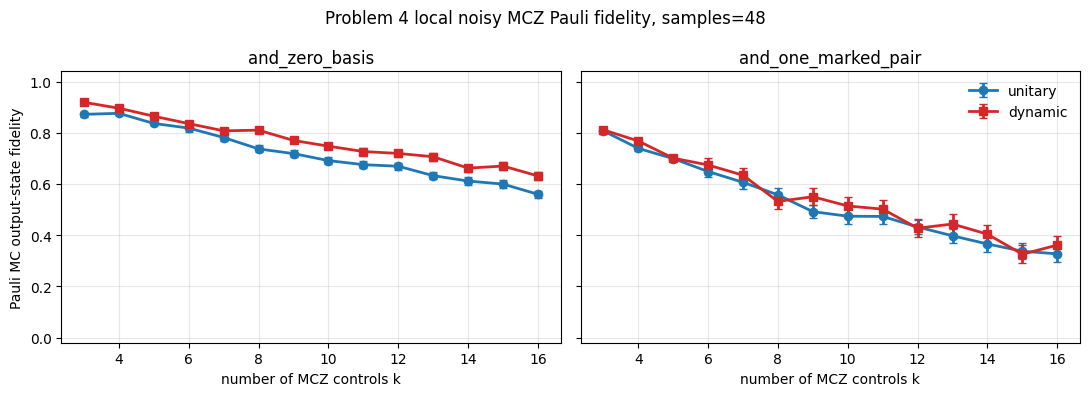

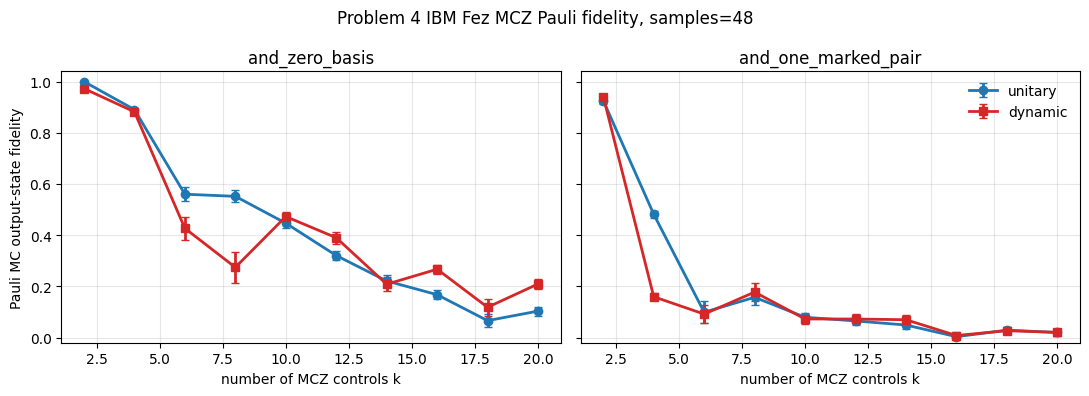

In [3]:
import matplotlib.pyplot as plt


def plot_fidelity_panels(results_df: pd.DataFrame, title: str, y_label: str = "Pauli MC output-state fidelity") -> None:
    input_labels = ["and_zero_basis", "and_one_marked_pair"]
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0), sharey=True)
    colors = {"unitary": "tab:blue", "dynamic": "tab:red"}
    markers = {"unitary": "o", "dynamic": "s"}
    for ax, input_label in zip(axes, input_labels):
        sub = results_df[results_df["input_label"] == input_label]
        for implementation in ["unitary", "dynamic"]:
            g = sub[sub["implementation"] == implementation].sort_values("num_controls")
            ax.errorbar(
                g["num_controls"],
                g["fidelity_estimate_clipped"],
                yerr=g["total_standard_error"] if "total_standard_error" in g else None,
                marker=markers[implementation],
                linewidth=2.0,
                capsize=3,
                color=colors[implementation],
                label=implementation,
            )
        ax.set_title(input_label)
        ax.set_xlabel("number of MCZ controls k")
        ax.set_ylim(-0.02, 1.04)
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel(y_label)
    axes[1].legend(frameon=False)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


local_combined_df = local_fidelity_df_48[local_fidelity_df_48["noise_model"] == "combined"].copy()
plot_fidelity_panels(local_combined_df, "Problem 4 local noisy MCZ Pauli fidelity, samples=48")
plot_fidelity_panels(hardware_fidelity_df, "Problem 4 IBM Fez MCZ Pauli fidelity, samples=48")

### Hardware Result Notes

The hardware table is loaded from the completed JSON records rather than only from `problem4_mcz_hardware_summary.csv`, because the CSV stores the actual number of Pauli terms in its `pauli_samples` column. That is correct for analysis but would hide the exact-all `k=2` and `k=4` rows if we filtered only on `pauli_samples == 48`.

The submitted circuits were transpiled with a restricted coupling map that excludes faulty/high-risk qubits and edges. The preflight and submitted metadata record the active physical qubits for each transpiled circuit.

## Next Steps Toward Grover

The functions above are designed to be embedded into larger algorithms:

- Use `apply_unitary_mcz(qc, controls, ancillas)` for a reversible oracle or diffuser block.
- Use `apply_dynamic_mcz(qc, controls, ancillas, measure_bits)` when the reverse AND tree can be replaced by measurement-uncompute.
- For Grover, first target the MCZ blocks in the phase oracle and diffuser. Keep the candidate block's work ancillas separate from any verifier or oracle scratch space.

Before hardware submission, the next engineering step is backend-specific transpilation and a native-gate accounting pass, because high-level `ccx` is only a logical placeholder here.


## Requested Fidelity Comparison

This figure compares the local noisy Pauli-fidelity sweep through `k <= 16` against the IBM Fez Pauli-fidelity hardware results through `k <= 40`. The plotted source values are saved in `log/problem4/problem4_requested_and_zero_fidelity_comparison.csv`.

/home/arnold/arnold/github/qhackathon_quantumjoa/log/problem4/problem4_requested_and_zero_fidelity_comparison.png
/home/arnold/arnold/github/qhackathon_quantumjoa/log/problem4/problem4_requested_and_zero_fidelity_comparison.csv


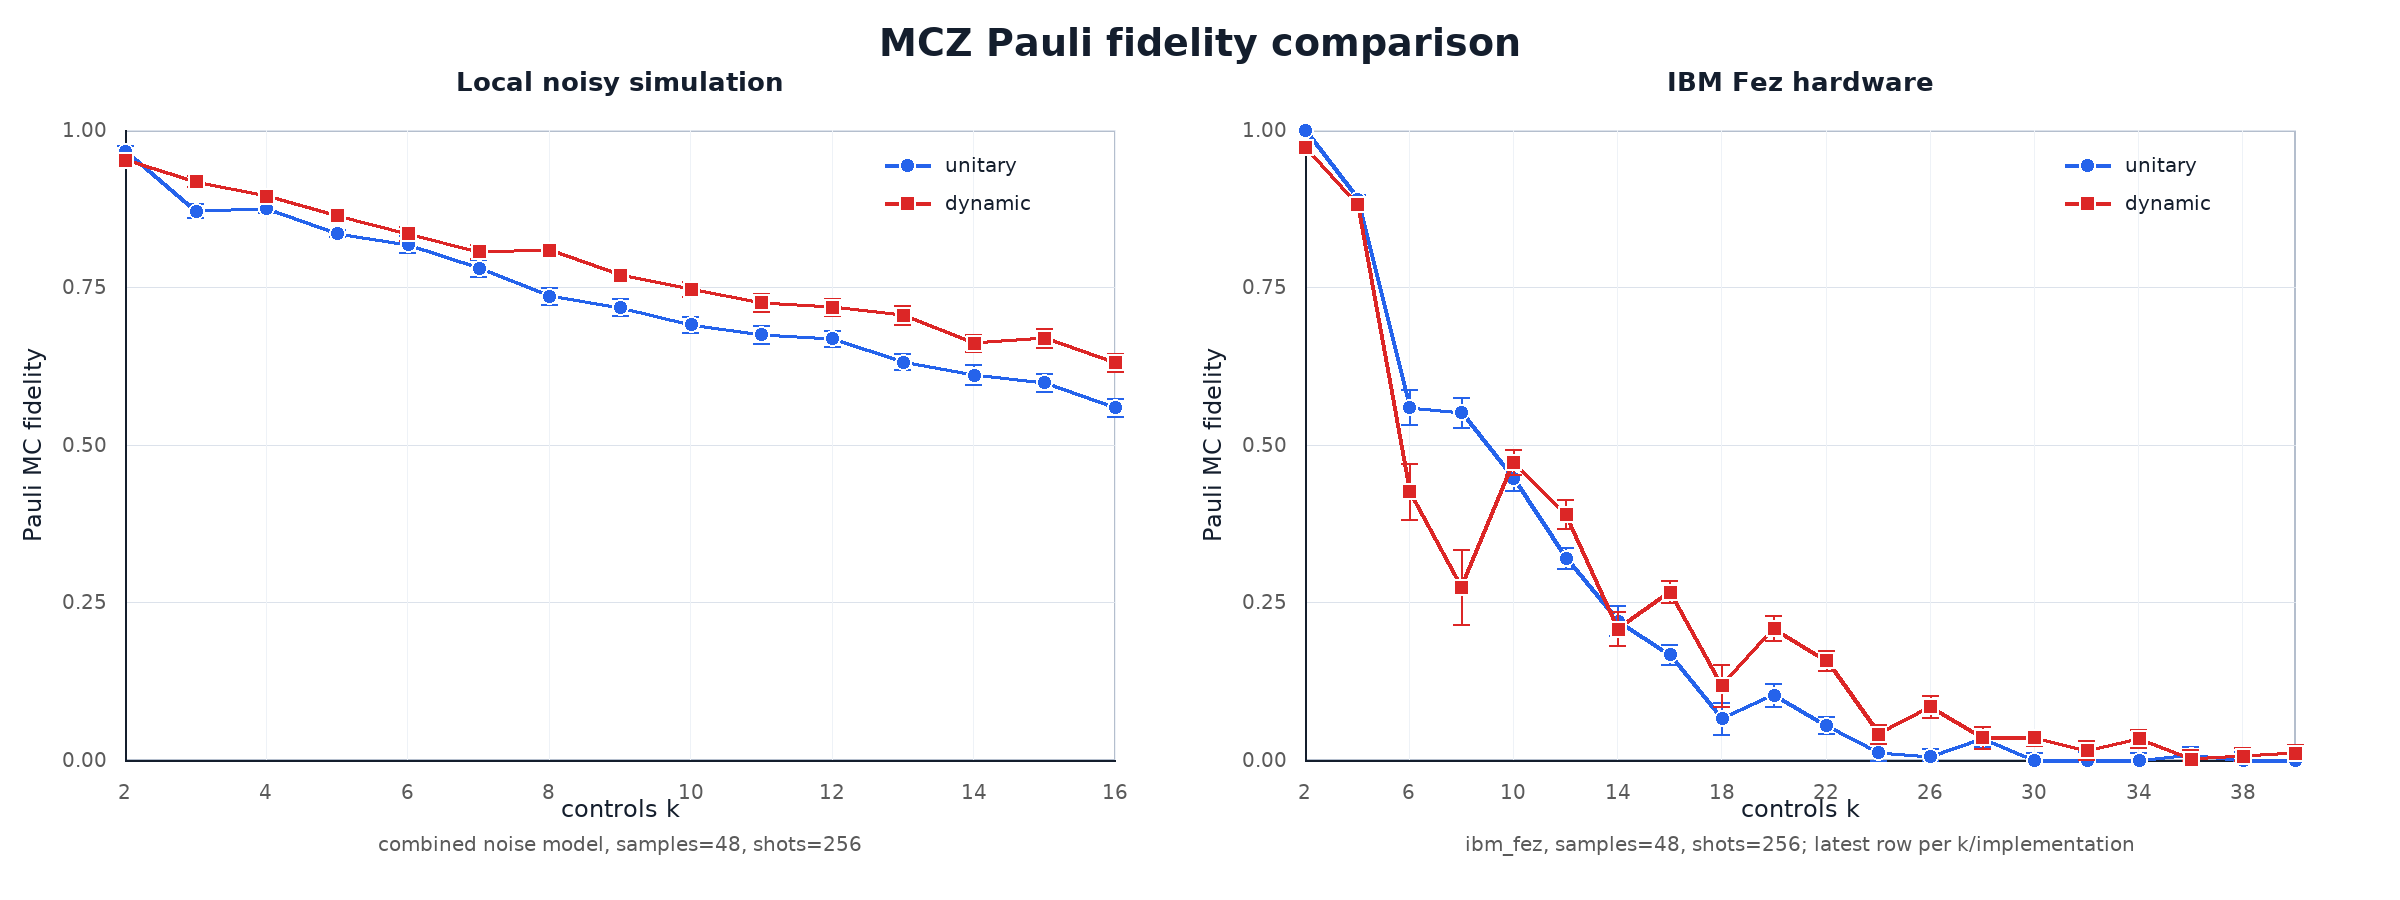

In [12]:
from pathlib import Path
from IPython.display import Image, display

requested_and_zero_plot = Path("log/problem4/problem4_requested_and_zero_fidelity_comparison.png")
requested_and_zero_summary = Path("log/problem4/problem4_requested_and_zero_fidelity_comparison.csv")
print(requested_and_zero_plot)
print(requested_and_zero_summary)
display(Image(filename=str(requested_and_zero_plot)))
